# Stimulus-locked 

In [1]:
import scipy.io
import io

from data_loader import DataLoader

import numpy as np
from utils import *
from matplotlib import pyplot as plt
import numpy.random as rng
import pandas as pd
from scipy.stats import spearmanr

import os

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
%run functions_to_use.ipynb

In [3]:
home_dir = os.path.abspath(os.path.curdir)
data_dir = os.path.join(home_dir, '..', 'Data')
ultralight = os.path.join(data_dir, 'GG-Dataset-Tulio-Ultralight')

In [4]:
rats = ['Rat08', 'Rat09', 'Rat10', 'Rat11']

def load_data(rats):
    return DataLoader(ultralight, 'Hpc', rats=[rats])

In [5]:
def session_vars():
    sessions = list(spks[rat].keys()) # for rat11 session 09, 18, 19, 24, 03 missing
    sessions.sort()
    session = sessions[session_idx]

    session_neurons = spks[rat][session]['all']
    neuron_ids = list(session_neurons.keys())
    n_neurons = len(neuron_ids)

    idx_start = list(data.events[rat][session]['cat']['data']).index('beginning run')
    start_time = data.events[rat][session]['cat']['ts'][idx_start]

    idx_end = list(data.events[rat][session]['cat']['data']).index('end run')
    end_time = data.events[rat][session]['cat']['ts'][idx_end]

    airpuff_times = data.events[rat][session]['puf']['ts']
    airpuff_times = [t for t in airpuff_times if t > start_time and t < end_time]

    return session, session_neurons, n_neurons, neuron_ids, start_time, end_time, airpuff_times

In [6]:
def spk_matrix_to_ranks(spk_matrix): 
    n_trials, n_neurons = spk_matrix.shape[0], spk_matrix.shape[1]
    
    ranks = np.full((n_trials, n_neurons), np.nan)  # Shape: [trials x neurons]
    
    for trial in range(n_trials):
        avg_spk_time = []
        for neuron_idx in range(n_neurons):
            spike_times = np.where(spk_matrix[trial, neuron_idx] == 1)[0]  
            if len(spike_times) > 0:  
                avg_spk_time.append(np.mean(spike_times))  
            else:
                avg_spk_time.append(np.nan)  

        avg_spk_time = np.array(avg_spk_time)

        neuron_sorted = np.argsort(avg_spk_time)
        valid_neurons = [neuron_idx for neuron_idx in neuron_sorted if not np.isnan(avg_spk_time[neuron_idx])]

        for rank, neuron_idx in enumerate(valid_neurons):
            ranks[trial, rank] = neuron_idx

    return ranks

In [7]:
def spk_puff_matrix(airpuff_events, time_frame, session_neurons):
    n_neurons = len(session_neurons.keys())
    n_puffs = len(airpuff_events)

    spk_puff_matrix = np.zeros((n_puffs, n_neurons, time_frame))
    
    for t, start_t in enumerate(airpuff_events):
        end_t = start_t + time_frame
        for i, (neuron_id, neuron_spk_time) in enumerate(session_neurons.items()):
            idx = np.where((neuron_spk_time >= start_t) & (neuron_spk_time < end_t))
            if len(idx)==0:
                continue
                
            spks_during_timeframe = neuron_spk_time[idx]
            spks_during_timeframe = np.floor((spks_during_timeframe - start_t)).astype(int)

            spk_puff_matrix[t, i, spks_during_timeframe] = 1

    return spk_puff_matrix

In [8]:
def spike_diagram(neuron_ids, spk_matrix_slice, session):
    plt.figure(figsize=(8, 8))
    n_trials, n_neurons, n_time_steps = spk_matrix_slice.shape

    for i, neuron_id in enumerate(neuron_ids):
        # Extract the spike data for the current neuron across all trials
        neuron_spikes = spk_matrix_slice[:, i, :]  # Shape: (10, 150)

        # Find spike times for each trial
        for trial_idx in range(n_trials):
            spike_times = np.where(neuron_spikes[trial_idx, :] >= 1)[0]  # Spikes in trial `trial_idx`
            plt.plot(spike_times, i + np.ones(len(spike_times)), 'k|', markersize=10)

    # Set up axis labels and title
    plt.yticks(ticks=np.arange(len(neuron_ids)), labels=neuron_ids)
    plt.xlabel('Time in ms')
    plt.ylabel('Neuron ID')
    plt.title(f'Spike Diagram with of session {session}')
    plt.show()

In [9]:
def shuffle_ranks(ranks):
    shuffled_ranks = ranks.copy()
    n_trials, n_neurons = ranks.shape[0], ranks.shape[1]

    for trial in range(n_trials):
        active_neuron_idxs = [idx for idx, val in enumerate(ranks[trial]) if not np.isnan(val)]
        active_neurons = [ranks[trial, idx] for idx in active_neuron_idxs]
    
        rng.shuffle(active_neurons)
    
        for idx, neuron in zip(active_neuron_idxs, active_neurons):
            shuffled_ranks[trial, idx] = neuron
    
    return shuffled_ranks

In [10]:
def MI_real_and_surrogates(spk_matrix, n_iterations):
    ranks = spk_matrix_to_ranks(spk_matrix)
    
    occ_actual = firing_ranks2occ_matrix(ranks)
    MI_actual = MI(occ_actual)
    
    surrogate_mi = np.empty(n_iterations, dtype=float)
    for i in range(n_iterations):
        shuffled_ranks = shuffle_ranks(ranks)
        occ_surrogate = firing_ranks2occ_matrix(shuffled_ranks)
        surrogate_mi[i] = MI(occ_surrogate)
    
    significance_boundary = np.percentile(surrogate_mi, 95)
    
    return MI_actual, occ_actual, surrogate_mi, significance_boundary


In [11]:
def MI(M):
    """
    Function made by Tom Has.
    Calculates the mutual information between the 2 axes of a matrix.
    Input:  - M:  2d matrix
    Output: - MI: Mutual information
    """
    sizex = M.shape[0]
    sizey = M.shape[1]
    total = np.sum(M)
    p_Y = np.sum(M, axis=0) / total
    p_X = np.sum(M, axis=1) / total
    # MI = sum over x and y: p(x,y) * log(p(x,y) / (p(x) * p(y)))
    #    = sum over x and y: M(x,y)/total * log((M(x,y) * total) / (p_X(x) * p_Y(y)))
    MI = sum([sum([(
        0 if M[x, y] == 0 else
        M[x, y] / total * np.log((M[x, y] / total) / (p_X[x] * p_Y[y]))
    ) for x in range(sizex)]) for y in range(sizey)])
    return MI

In [12]:
def firing_ranks2occ_matrix(firing_ranks):
    """
    Constructs an occurrence matrix from firing ranks where occ[x, y] represents how often neuron x had rank y.
    Input:  - firing_ranks: Array containing for each rank in each trial which neuron had this rank in this trial
    Output: - occ:          Occurrence matrix
    """
    n_neurons = firing_ranks.shape[1]
    occ = np.zeros((n_neurons, n_neurons), dtype=int)
    # Loop over trials
    for trial in firing_ranks:
        # Loop over ranks:
        for rank, neuron in enumerate(trial):
            if np.isnan(neuron):
                continue
            # For not nan rank, neuron pairs, increment the respective square in the occurrence matrix|
            occ[int(neuron), rank] += 1
    return occ

In [13]:
def sort_occ_matrix(occ_matrix, mean_rank=False):   
    """"
    Modifies an occ matrix to only active neurons and 'used' rank positions. 
    Also, it sorts the matrix, either based on mean rank, or on mode rank.
    """
    # Find active neurons
    active_neurons = np.where(np.any(occ_matrix>0, axis=1))[0]

    # Find non-zero rank range
    active_ranks = np.where(np.any(occ_matrix!=0, axis=0))[0]
    if len(active_ranks)<=1:
        rank_limit_1 = 1
        rank_limit_2 = 2
    else:
        rank_limit_1 = active_ranks[1]
        rank_limit_2 = active_ranks[-1]

    # Pick 'active' rows of occ_matrix, for relevant rank range
    occ_matrix = occ_matrix[active_neurons, rank_limit_1:rank_limit_2+1]
    
    # Compute max rank
    max_ranks = np.argmax(occ_matrix, axis=1)
    
    # Compute mean rank
    mean_ranks = np.zeros(len(active_neurons))
    for ineuron, neuron in enumerate(active_neurons):
        mean_ranks[ineuron] = np.mean(occ_matrix[ineuron,:]*np.arange(rank_limit_1, rank_limit_2+1))
    
    
    # Return sorted occ matrix
    if mean_rank:
        return [occ_matrix[np.argsort(mean_ranks),:], np.argsort(mean_ranks), active_neurons]
    else:
        return [occ_matrix[np.argsort(max_ranks),:], np.argsort(max_ranks), active_neurons]

In [14]:
def plot_surrogates(surrogates, boundary, mi_values, ax, idx):
    ax.hist(surrogates, bins=20, color='gray', alpha=0.7, label='Surrogate MI')
    ax.axvline(boundary, color='grey', linestyle='dashed', linewidth=2, label=f'95th Percentile: {boundary:.2f}')
    ax.axvline(mi_values, color='red', linestyle='dashed', linewidth=2, label=f'Real MI: {mi_values:.2f}')
    # ax.set_xlim(0, 1.1)
    ax.set_xlabel('Mutual Information')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Surrogate MI Values of session {idx}')
    ax.legend()

In [15]:
def zscore_by_surr(real_MI, surr_MI):
    m = np.mean(surr_MI)
    s = np.std(surr_MI)
    real_MI = (real_MI-m)/s
    return real_MI

In [16]:
def MI_real_and_surrogates_zscore(spk_matrix, n_iterations):
    ranks = spk_matrix_to_ranks(spk_matrix)
    occ_actual = firing_ranks2occ_matrix(ranks)
    MI_actual = MI(occ_actual)
    
    surrogate_mi = np.empty(n_iterations, dtype=float)
    for i in range(n_iterations):
        shuffled_ranks = shuffle_ranks(ranks)
        occ_surrogate = firing_ranks2occ_matrix(shuffled_ranks)
        surrogate_mi[i] = MI(occ_surrogate)
    
    significance_boundary = np.percentile(surrogate_mi, 95)
    
    zscored_MI_actual = zscore_by_surr(MI_actual, surrogate_mi)
    zscored_surrogate_mi = zscore_by_surr(surrogate_mi, surrogate_mi)  # This centers the surrogates around 0
    zscored_boundary = zscore_by_surr(significance_boundary, surrogate_mi)
    
    return MI_actual, occ_actual, zscored_surrogate_mi, zscored_boundary, zscored_MI_actual


# Find values for all sessions of a single rat

Rat 8 (5 could be a nice sequence to show from occ!)

/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:402: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat08/Rat08-20130722/States.mat
  self.__warning_msg(self.paths[rat][session]['States'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat08/Rat08-20130722/Rat08-20130722.rip.evt
  self.__warning_msg(path)
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat08/Rat08-20130718/Rat08-20130718.rip.evt
  self.__warning_msg(path)
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-proj

0 Session being processed is: Rat08-20130708


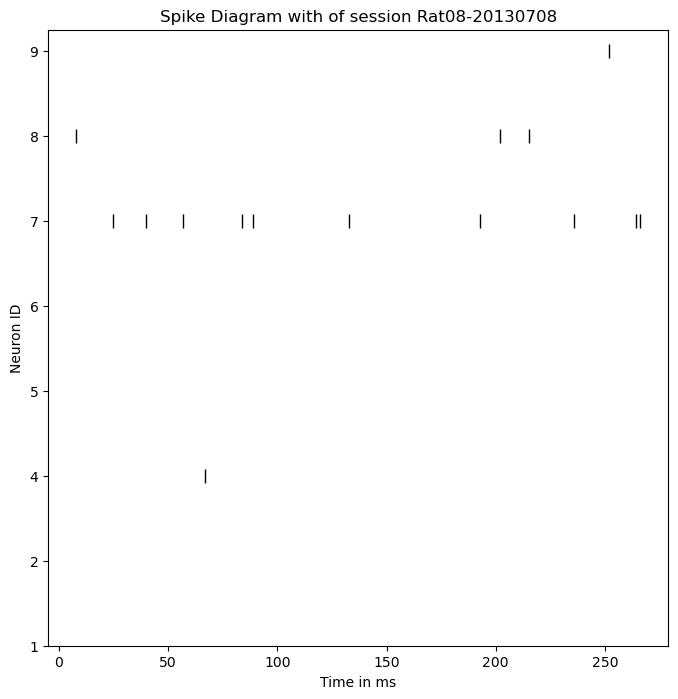

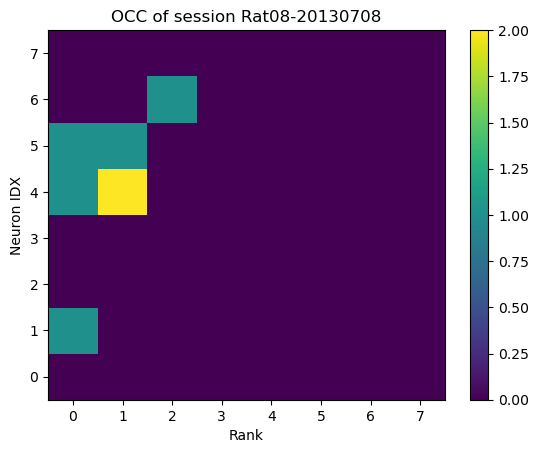

1 Session being processed is: Rat08-20130709


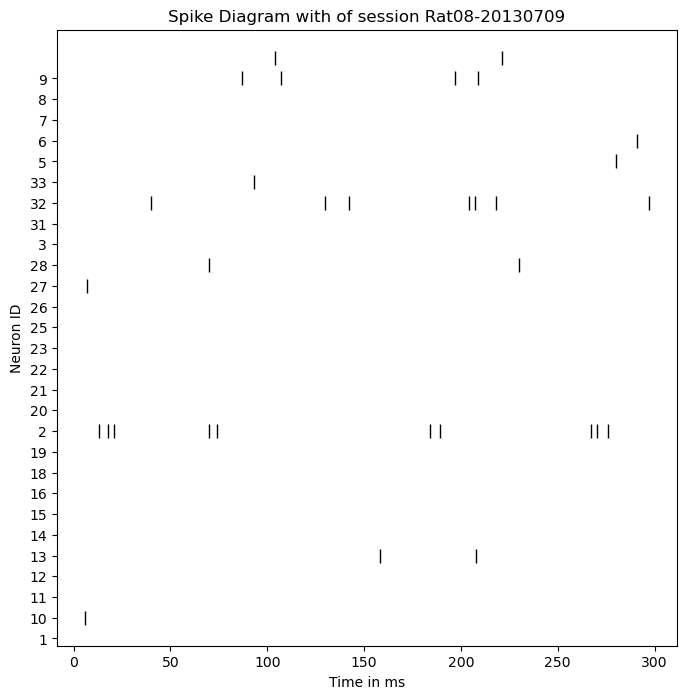

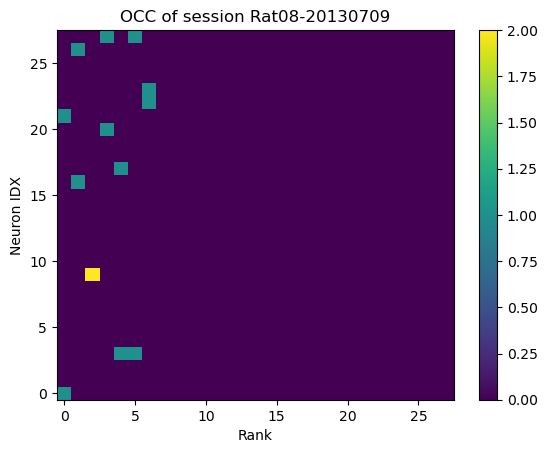

4 Session being processed is: Rat08-20130712


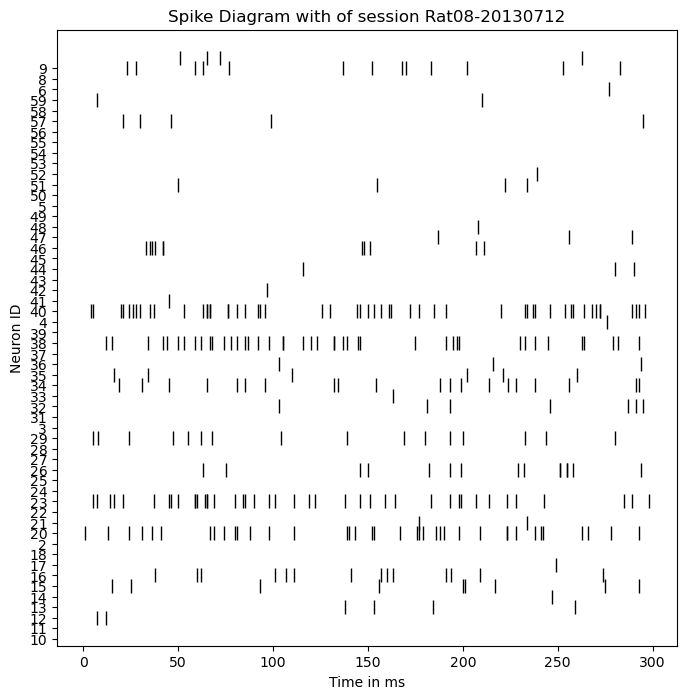

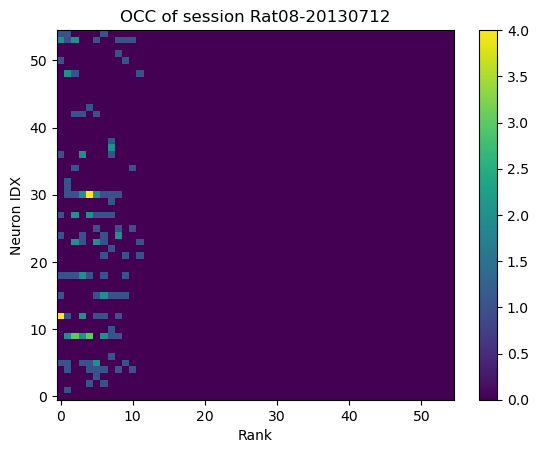

5 Session being processed is: Rat08-20130713


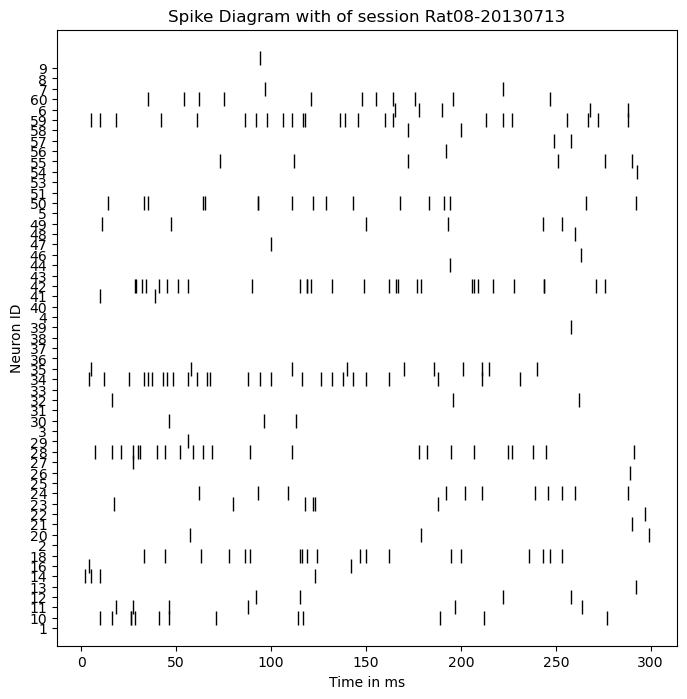

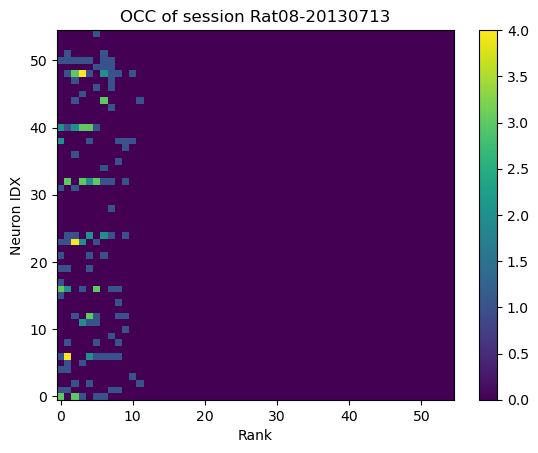

6 Session being processed is: Rat08-20130715


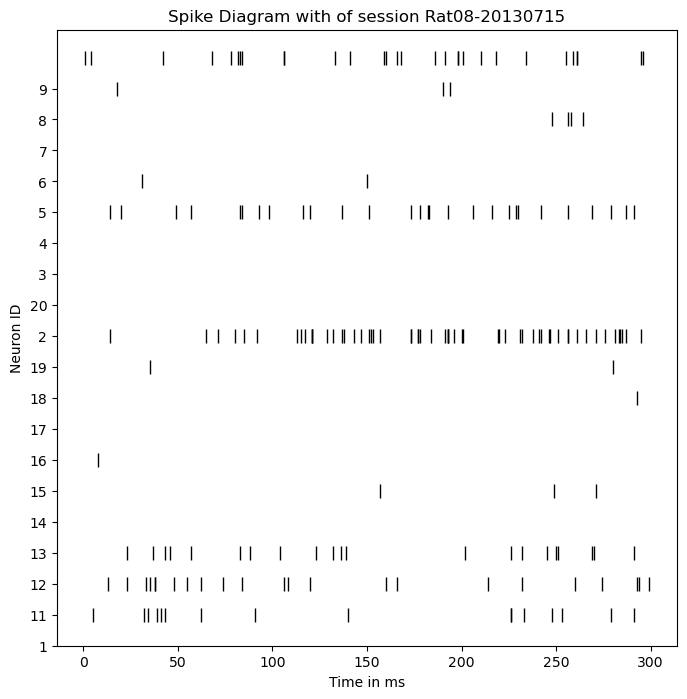

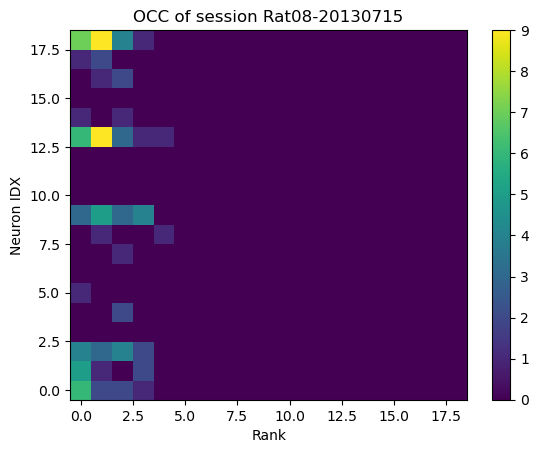

7 Session being processed is: Rat08-20130716


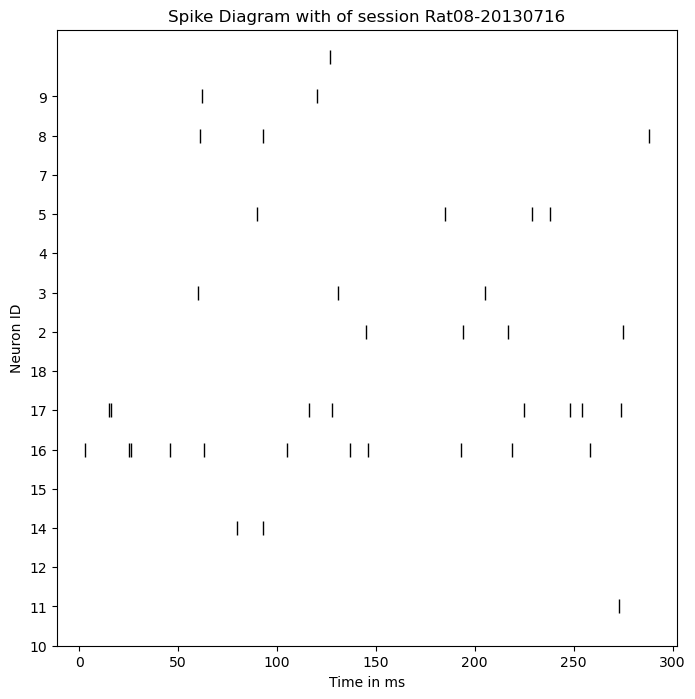

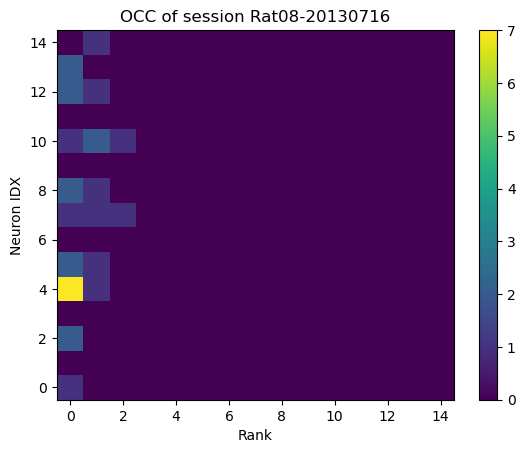

In [17]:
data = load_data('Rat08')
spks = data.get_spk()
rat_id = 0
rat = rats[rat_id]

n_sessions = 8
MI_all_sessions  = np.zeros(n_sessions)
boundary_all_sessions = np.zeros(n_sessions)
surrogate_MI_all_sessions = np.zeros((n_sessions, 1000), dtype=float)

for s in range(n_sessions):
    if s == 2 or s == 3 or s == 8: # for rat 8
         continue
    session_idx = s
    session, session_neurons, n_neurons, neuron_ids, start_t, end_t, puffs = session_vars()
    print(s, f"Session being processed is: {session}")
    
    spk_airpuff_matrix = spk_puff_matrix(puffs, 300, session_neurons)
    mi, occ, surrogates, boundary = MI_real_and_surrogates(spk_airpuff_matrix, 1000)
    MI_all_sessions[s] = mi
    boundary_all_sessions[s] = boundary
    surrogate_MI_all_sessions[s] = surrogates

    spike_diagram(neuron_ids, spk_airpuff_matrix, session)

    plt.imshow((occ), aspect='auto', origin='lower')
    plt.xlabel('Rank')
    plt.ylabel('Neuron IDX')
    plt.colorbar()
    plt.title(f"OCC of session {session}")
    plt.show()

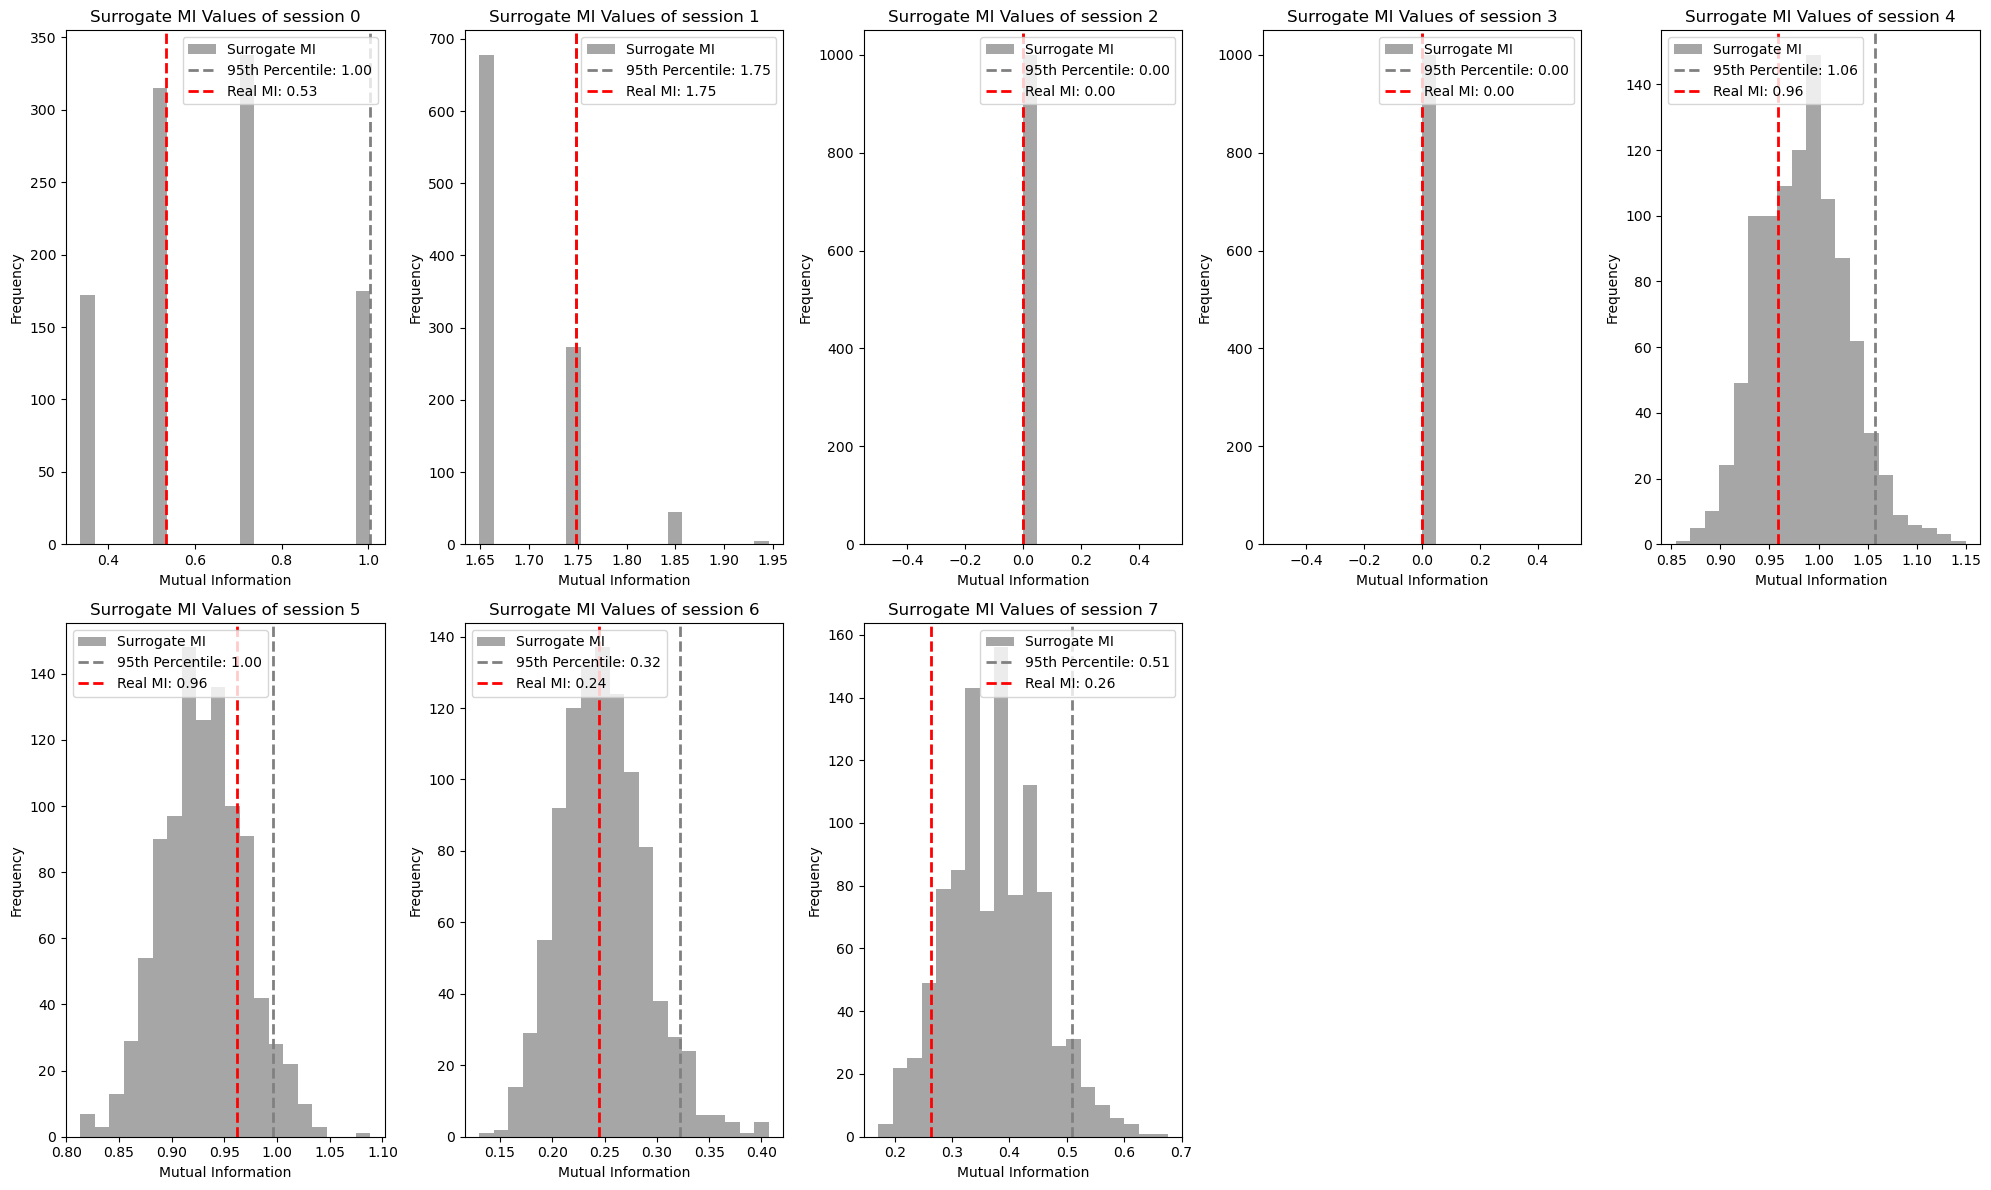

In [18]:
num_plots = n_sessions
cols = 5
rows = (num_plots + cols - 1) // cols  # Ceiling division

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 12))
axes = axes.flatten()  # Flatten to make indexing easier

# Loop through and plot
for n in range(num_plots):
    plot_surrogates(surrogate_MI_all_sessions[n], boundary_all_sessions[n], MI_all_sessions[n], axes[n], n)

# Hide unused subplots
for ax in axes[num_plots:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat10/Rat10-20140704/Rat10-20140704-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])


0 Session being processed is: Rat10-20140619


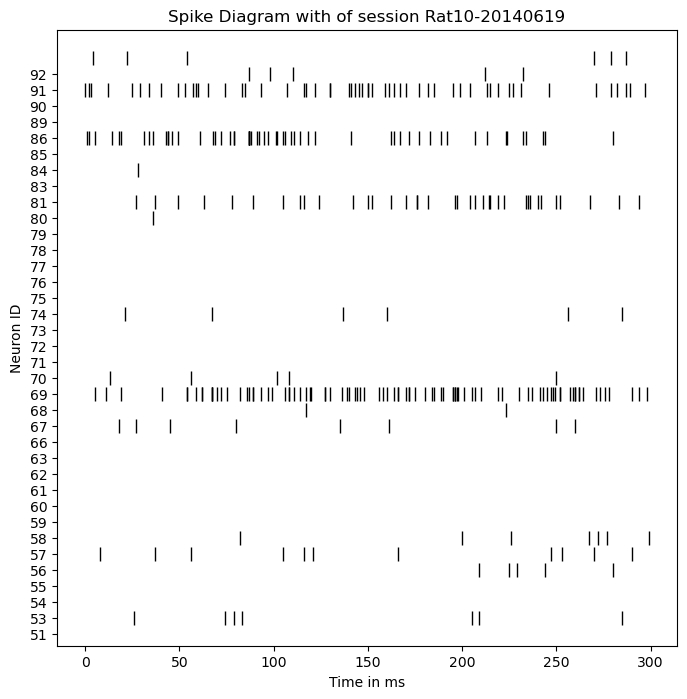

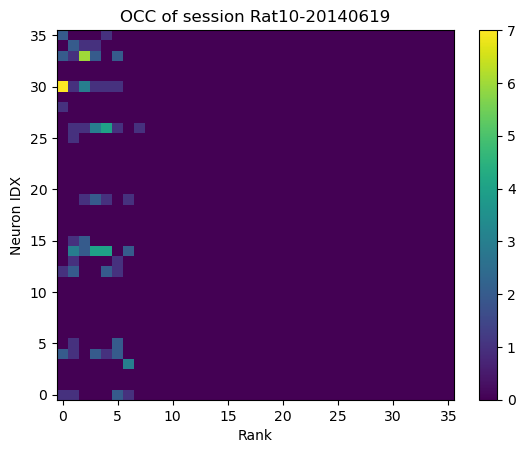

1 Session being processed is: Rat10-20140620


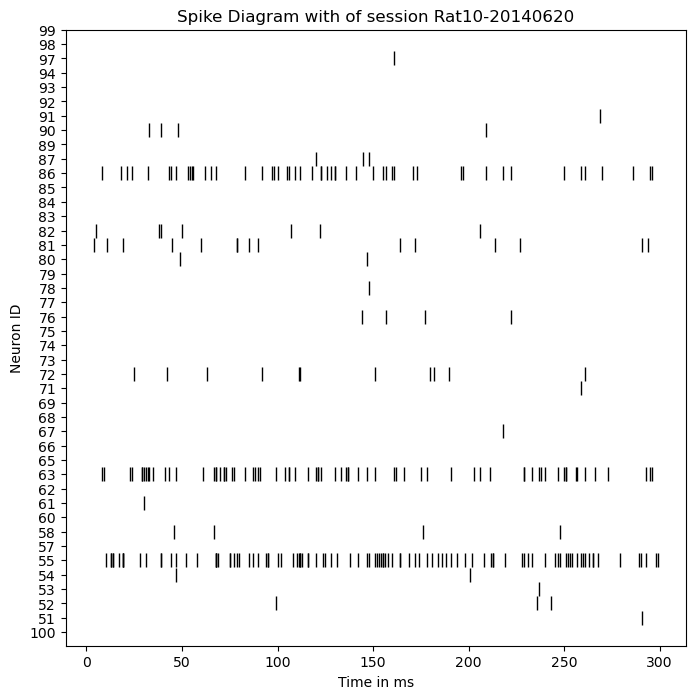

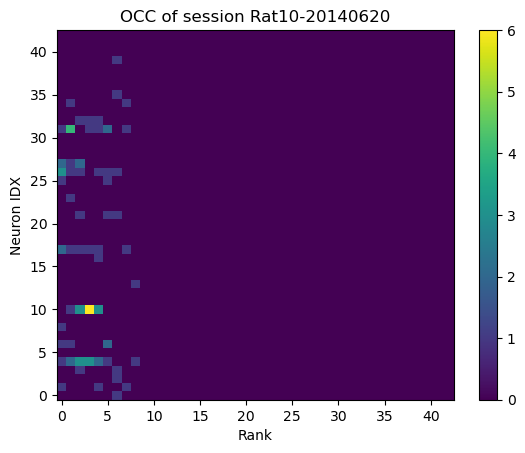

2 Session being processed is: Rat10-20140622


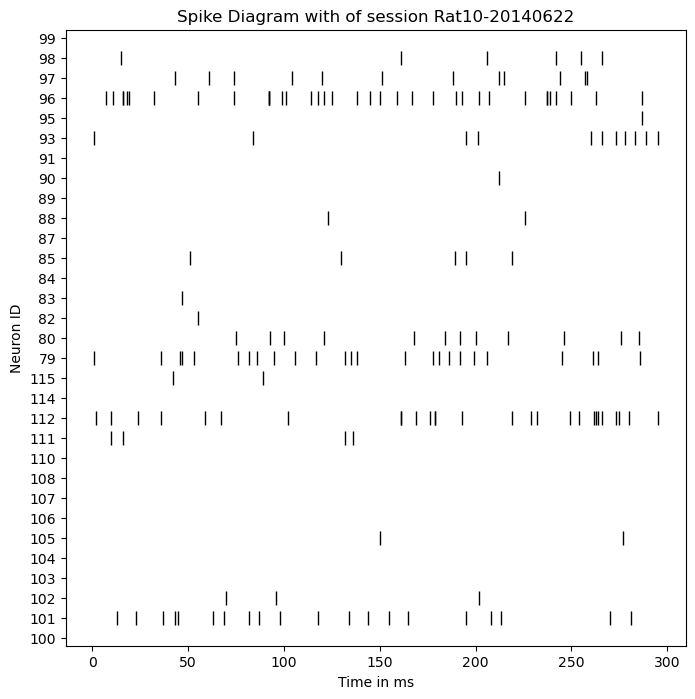

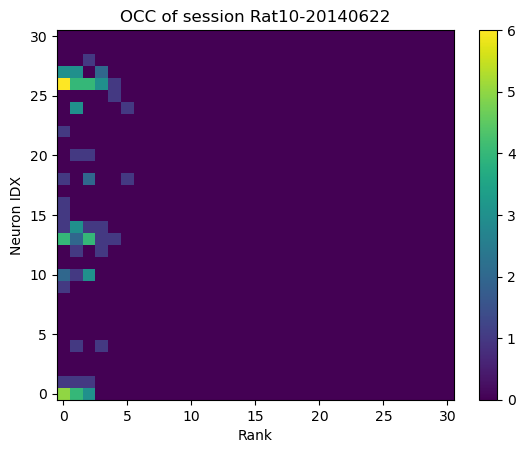

3 Session being processed is: Rat10-20140624


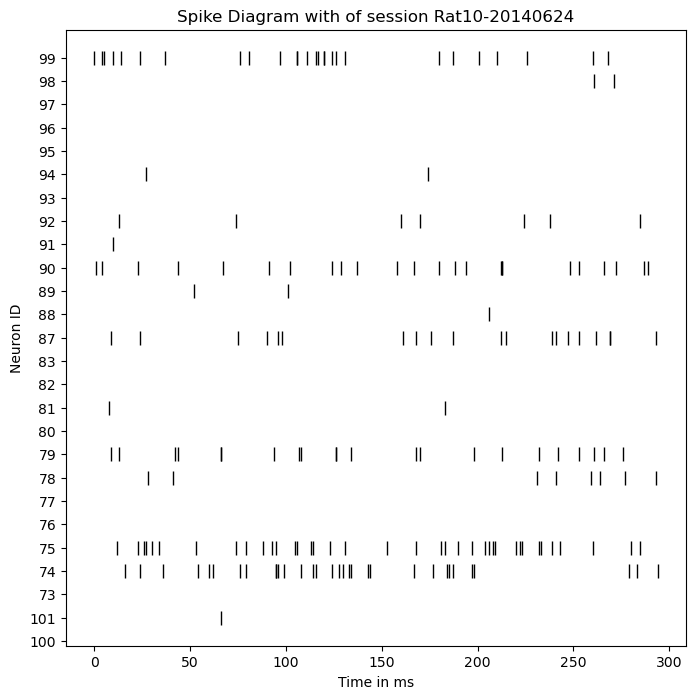

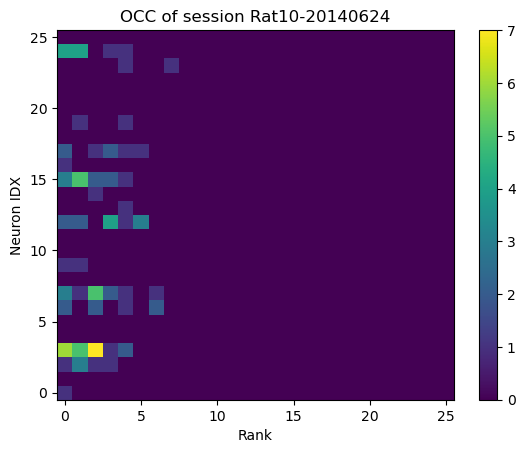

4 Session being processed is: Rat10-20140626


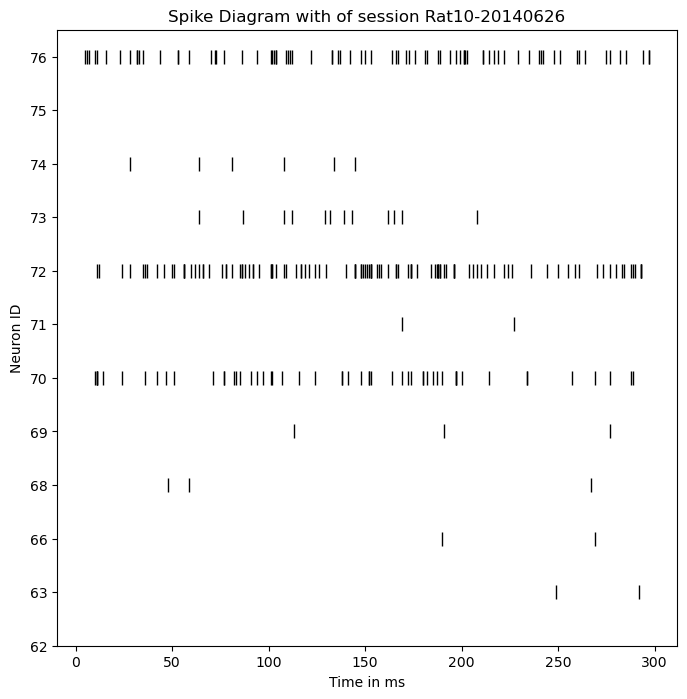

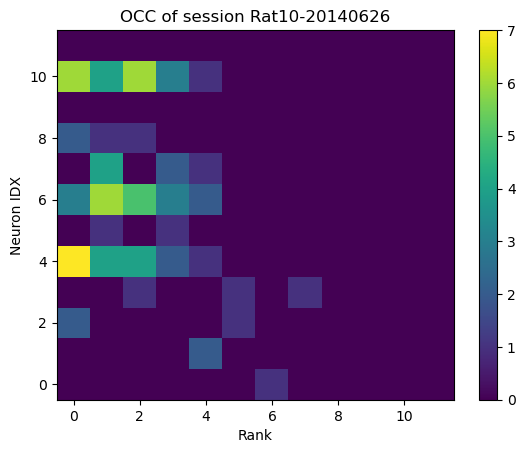

5 Session being processed is: Rat10-20140627


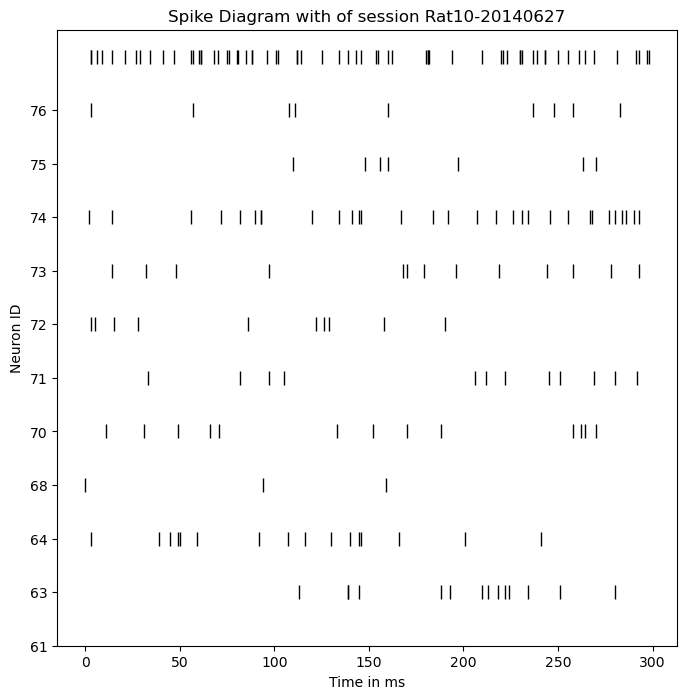

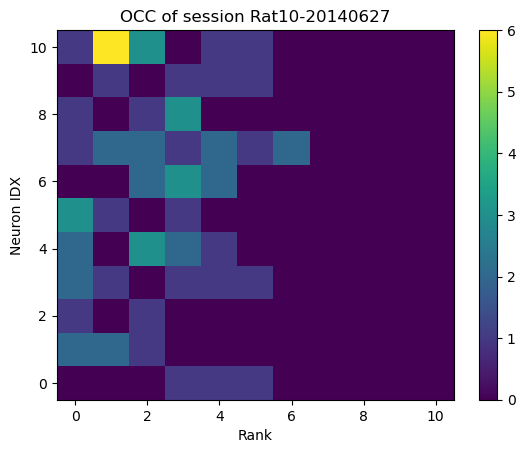

6 Session being processed is: Rat10-20140628


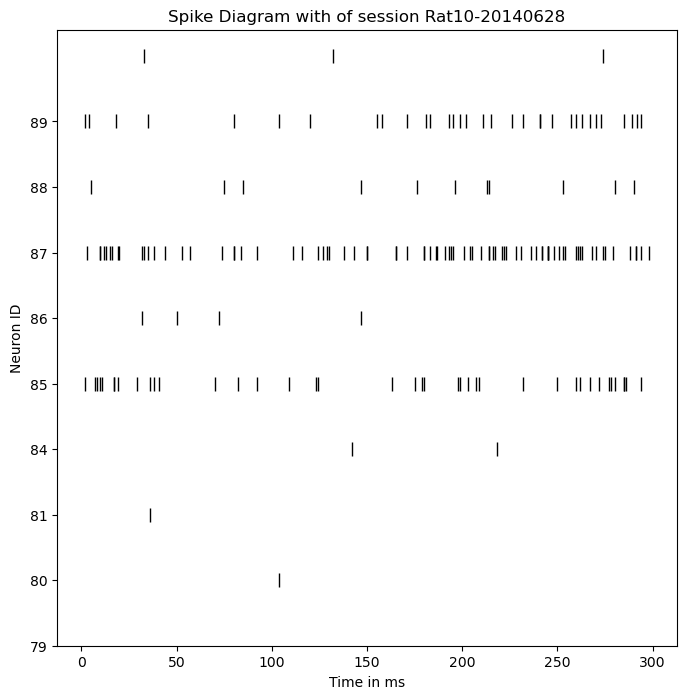

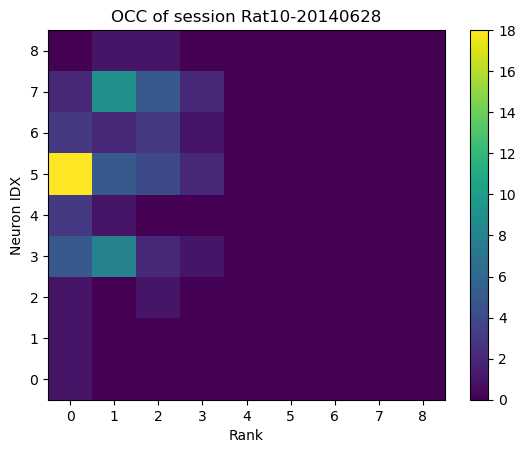

7 Session being processed is: Rat10-20140629


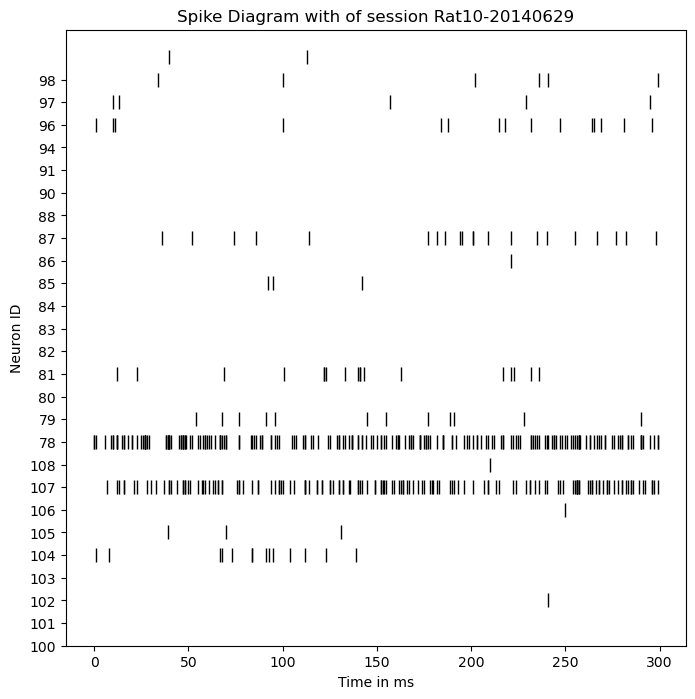

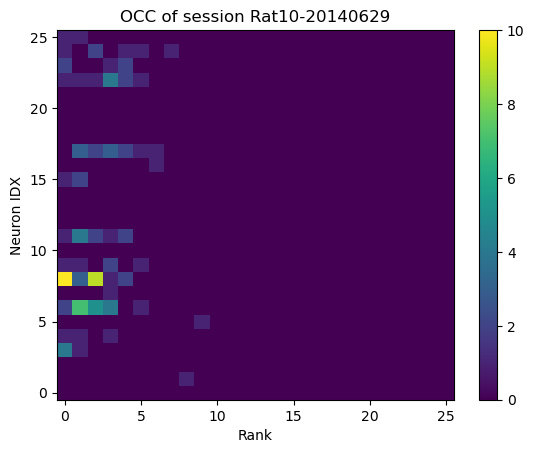

8 Session being processed is: Rat10-20140701


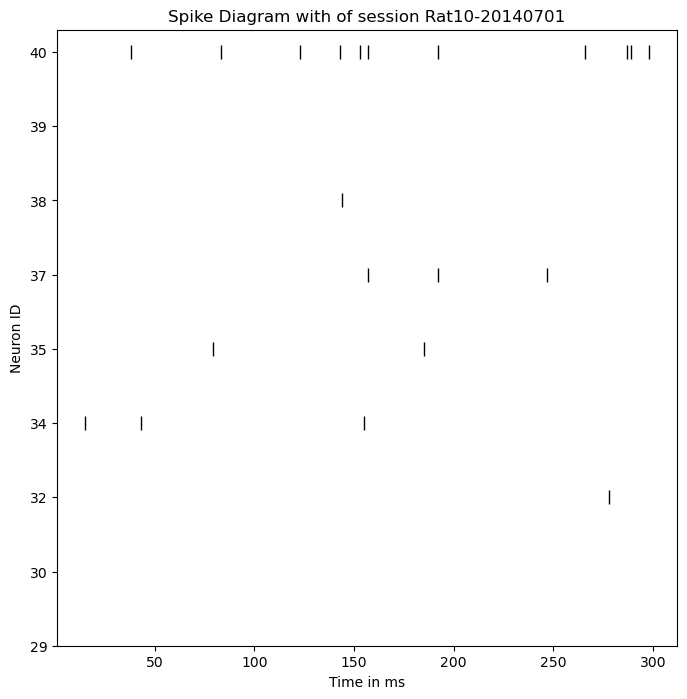

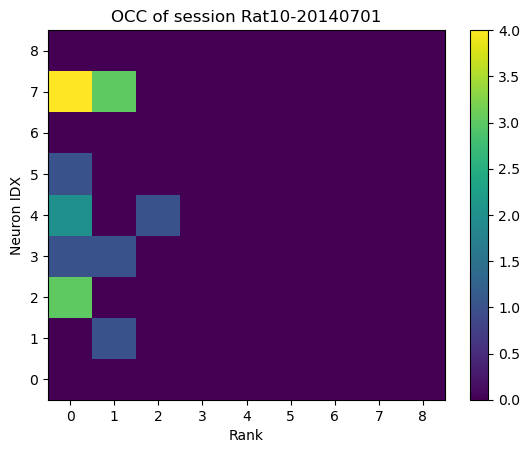

9 Session being processed is: Rat10-20140702


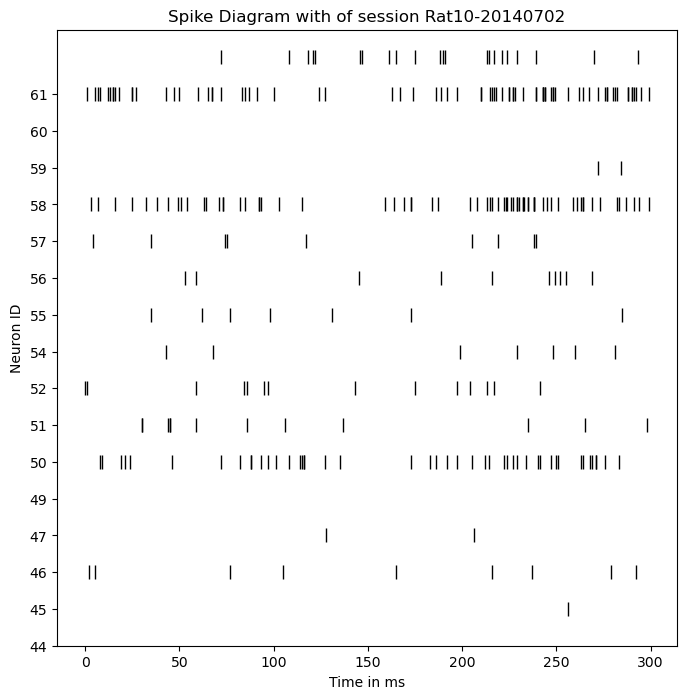

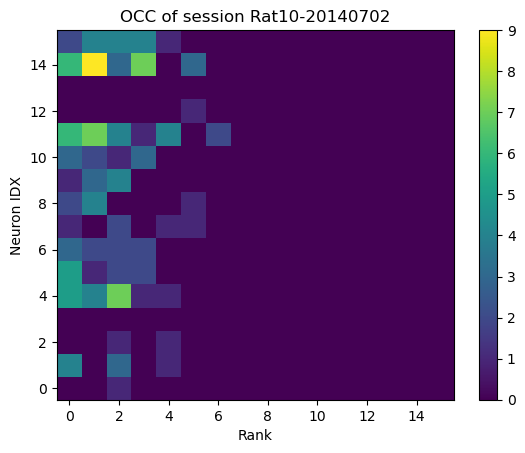

11 Session being processed is: Rat10-20140704


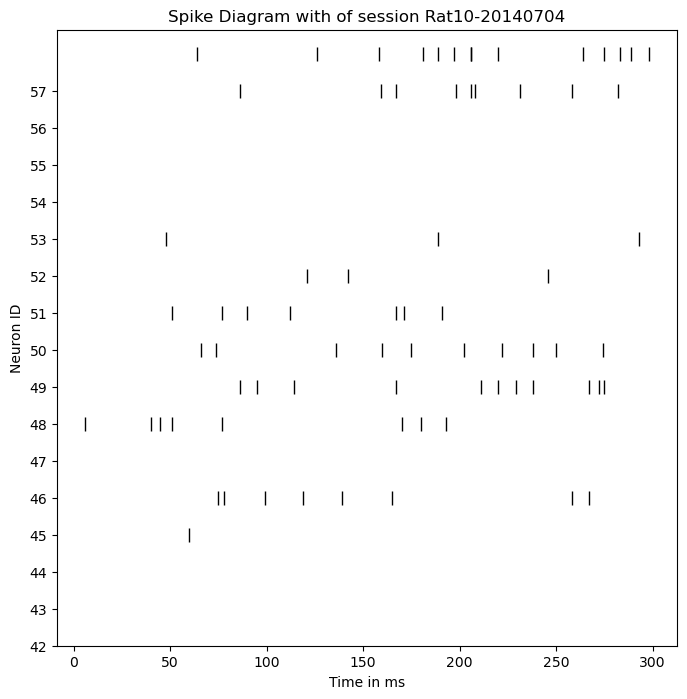

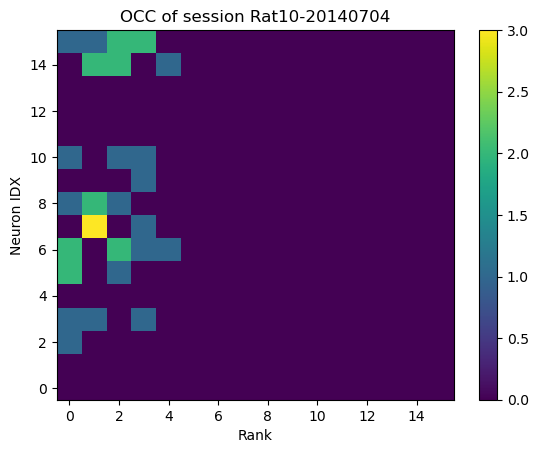

12 Session being processed is: Rat10-20140705


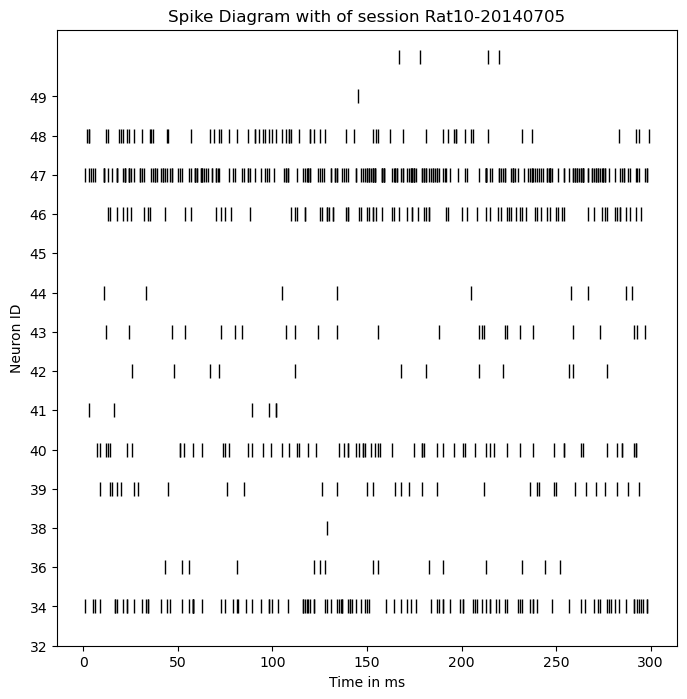

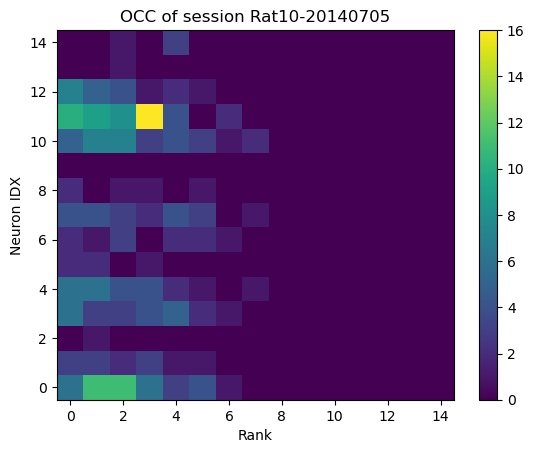

14 Session being processed is: Rat10-20140708


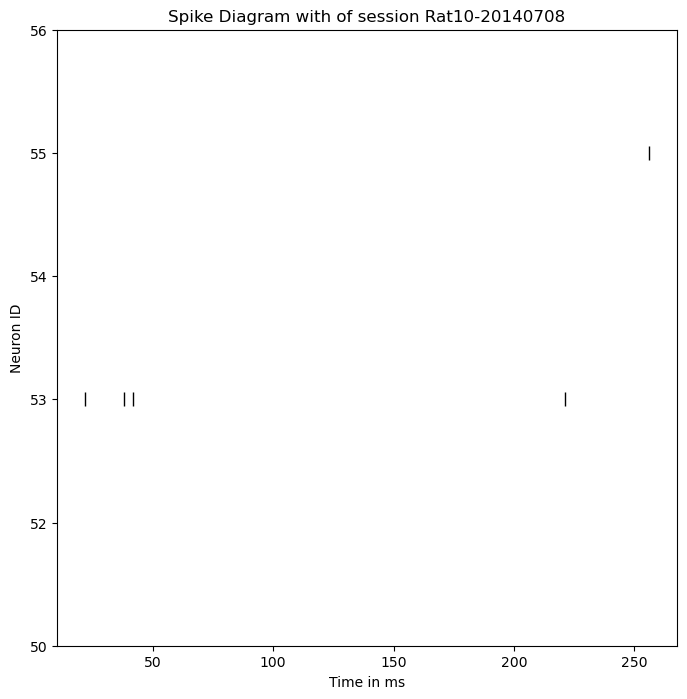

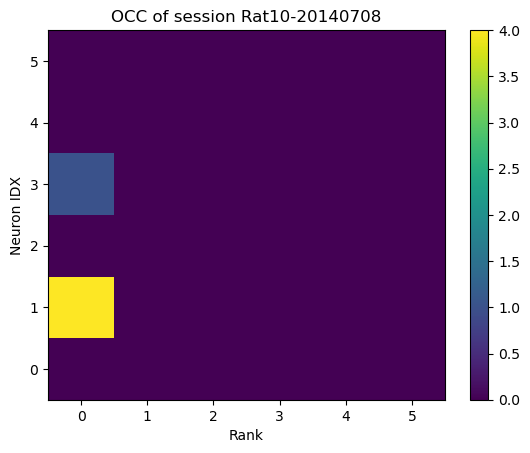

In [19]:
data = load_data('Rat10')
spks = data.get_spk()
rat_id = 2
rat = rats[rat_id]

n_sessions = 15
MI_all_sessions  = np.zeros(n_sessions)
boundary_all_sessions = np.zeros(n_sessions)
surrogate_MI_all_sessions = np.zeros((n_sessions, 1000), dtype=float)

for s in range(n_sessions):
    if s == 10 or s == 13: # for rat 10
         continue
    session_idx = s
    session, session_neurons, n_neurons, neuron_ids, start_t, end_t, puffs = session_vars()
    print(s, f"Session being processed is: {session}")
    
    spk_airpuff_matrix = spk_puff_matrix(puffs, 300, session_neurons)
    mi, occ, surrogates, boundary = MI_real_and_surrogates(spk_airpuff_matrix, 1000)
    MI_all_sessions[s] = mi
    boundary_all_sessions[s] = boundary
    surrogate_MI_all_sessions[s] = surrogates

    spike_diagram(neuron_ids, spk_airpuff_matrix, session)

    plt.imshow((occ), aspect='auto', origin='lower')
    plt.xlabel('Rank')
    plt.ylabel('Neuron IDX')
    plt.colorbar()
    plt.title(f"OCC of session {session}")
    plt.show()

/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat10/Rat10-20140704/Rat10-20140704-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])


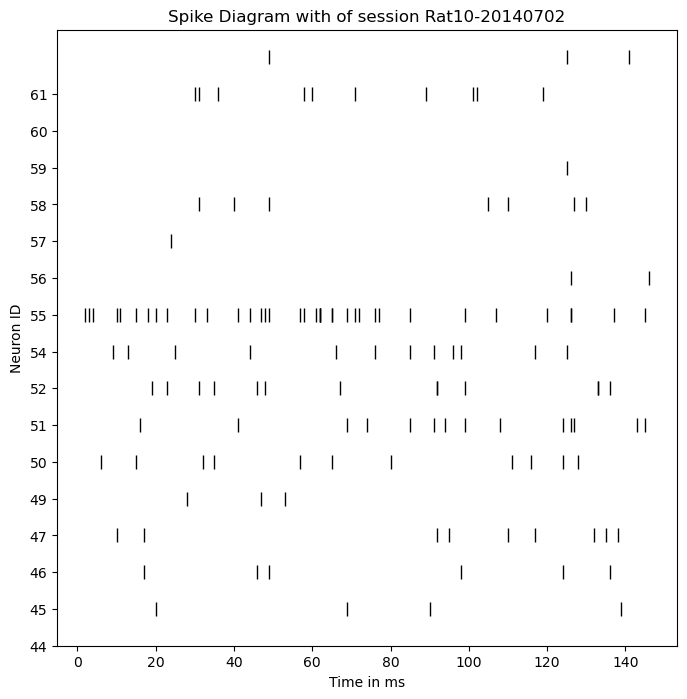

[11. 12. 13. 14. 37.] [4 7 6 5 8]


In [20]:
session_idx = 9
session, session_neurons, n_neurons, neuron_ids, start_t, end_t, puffs = session_vars()
safe_moments = find_safe_moments(session, start_t, end_t)
spk_airpuff_matrix = spk_puff_matrix(safe_moments, 150, session_neurons)
spike_diagram(neuron_ids, spk_airpuff_matrix, session)
# print(neuron_ids[40], neuron_ids[39], neuron_ids[59], neuron_ids[71])
sum_per_neuron = np.sum(spk_airpuff_matrix, axis=(0, 2))
top_5_indices = np.argsort(sum_per_neuron)[-5:]  
top_5_values = sum_per_neuron[top_5_indices]
print(top_5_values, top_5_indices)

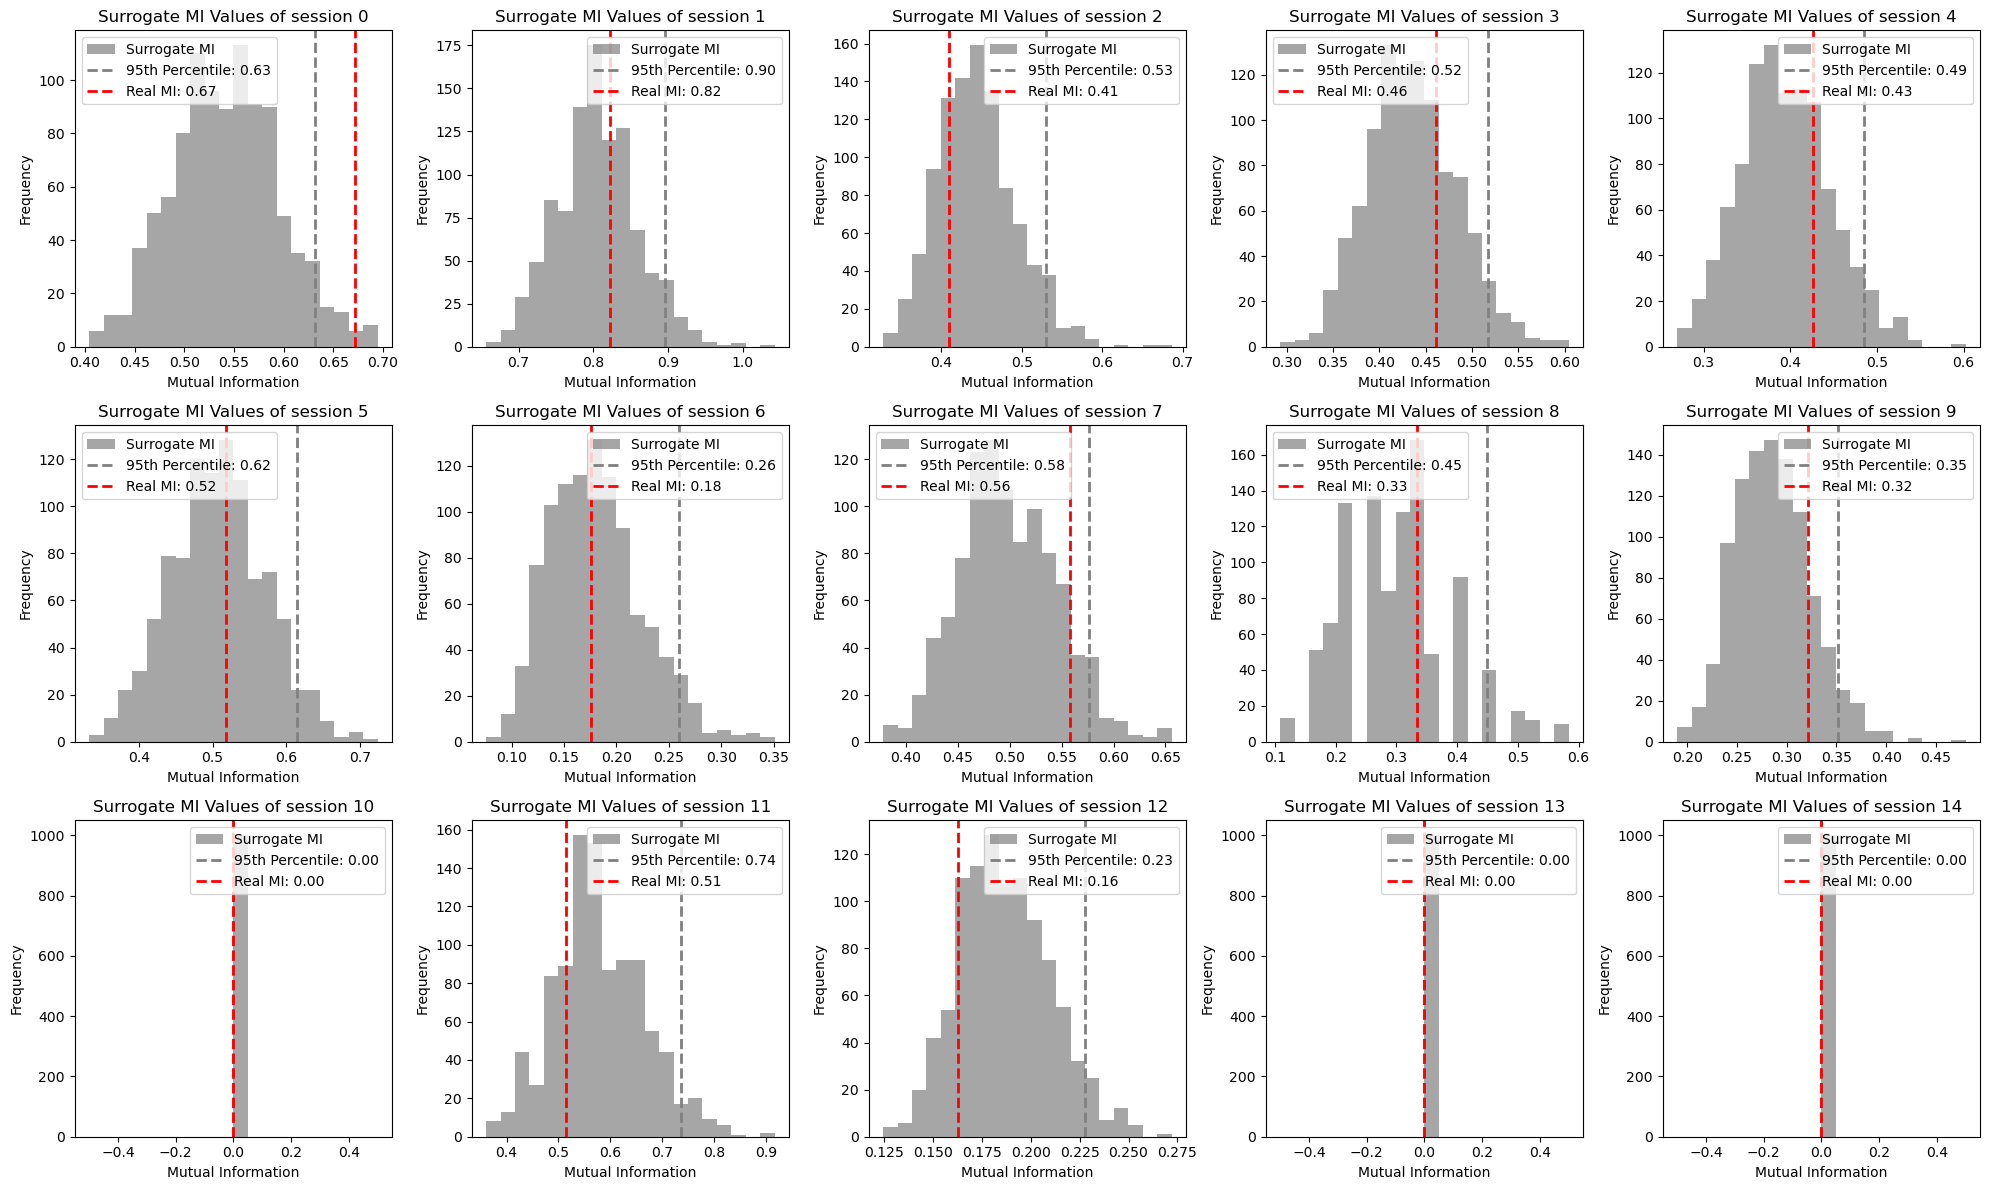

In [21]:
num_plots = n_sessions
cols = 5
rows = (num_plots + cols - 1) // cols  # Ceiling division

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 12))
axes = axes.flatten()  # Flatten to make indexing easier

# Loop through and plot
for n in range(num_plots):
    plot_surrogates(surrogate_MI_all_sessions[n], boundary_all_sessions[n], MI_all_sessions[n], axes[n], n)

# Hide unused subplots
for ax in axes[num_plots:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Rat 11

/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150402/Rat11-20150402.puf.evt
  self.__warning_msg(path)
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150318/Rat11-20150318-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150315/Rat11-20150315-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/larav

0 Session being processed is: Rat11-20150310


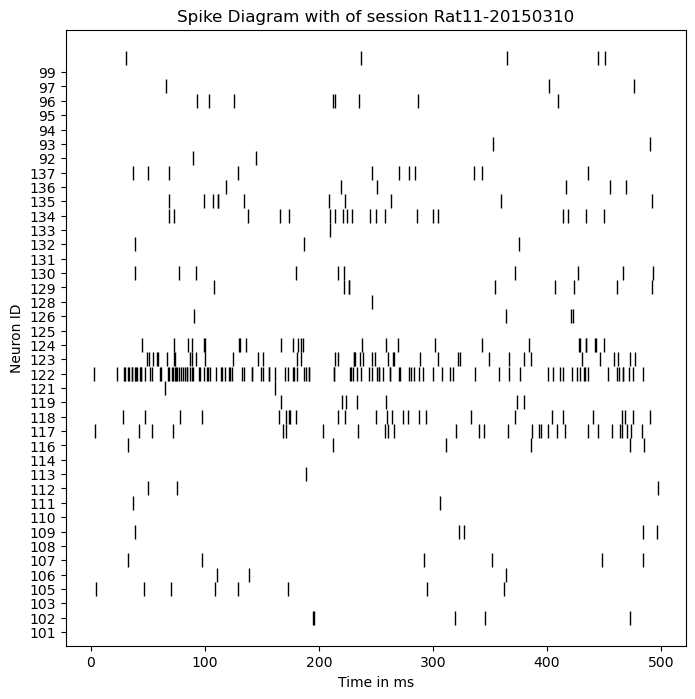

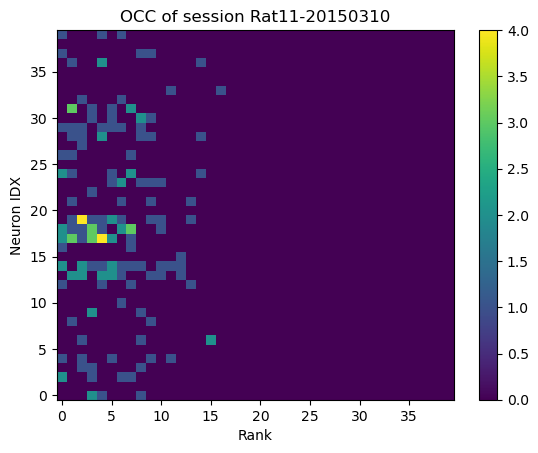

1 Session being processed is: Rat11-20150312


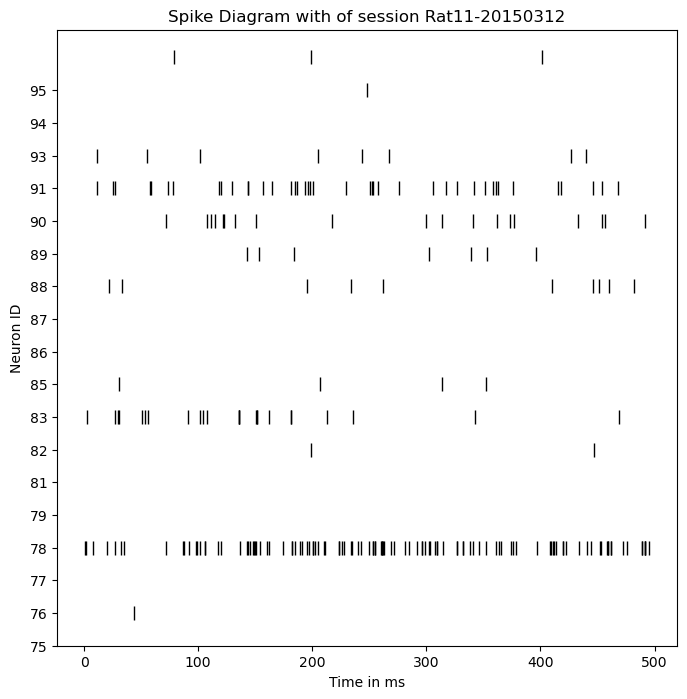

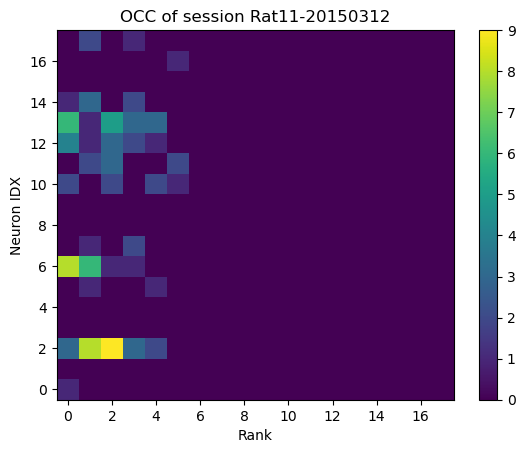

2 Session being processed is: Rat11-20150313


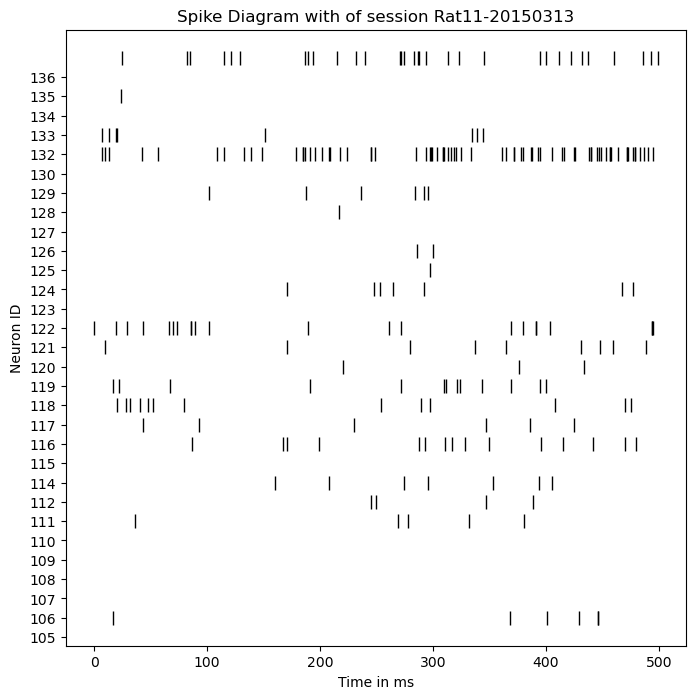

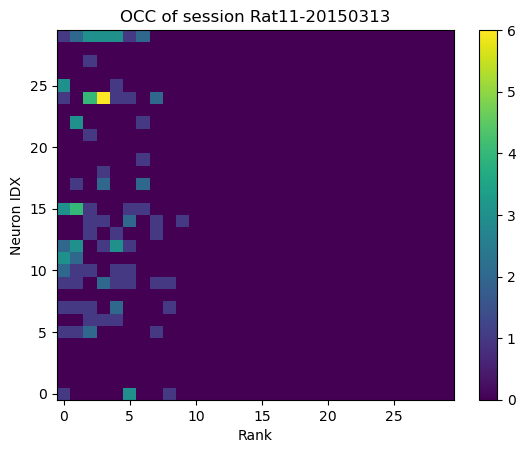

3 Session being processed is: Rat11-20150314


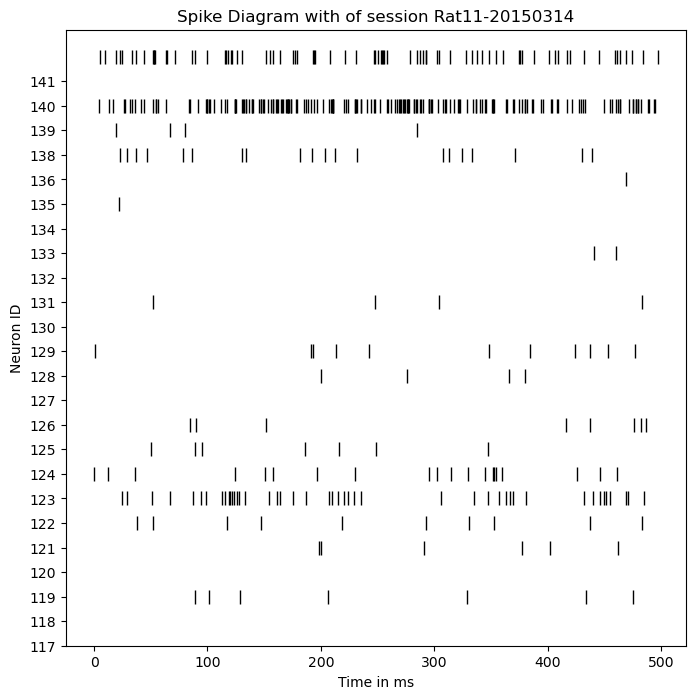

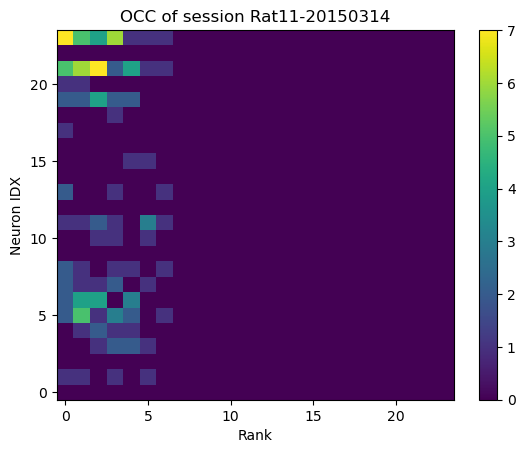

4 Session being processed is: Rat11-20150315


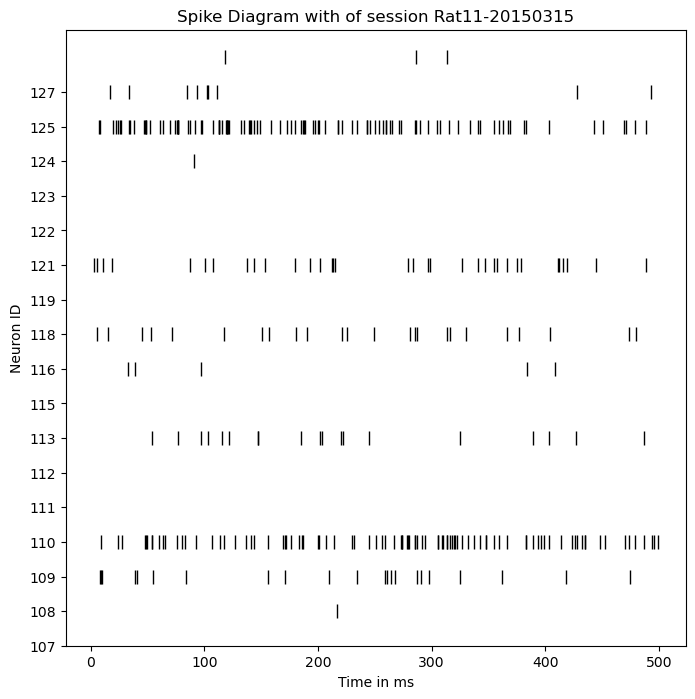

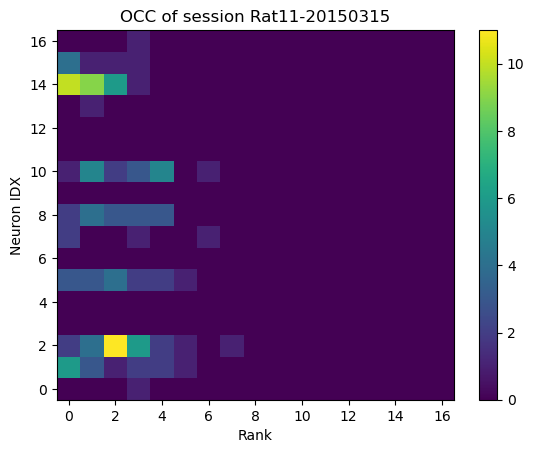

5 Session being processed is: Rat11-20150316


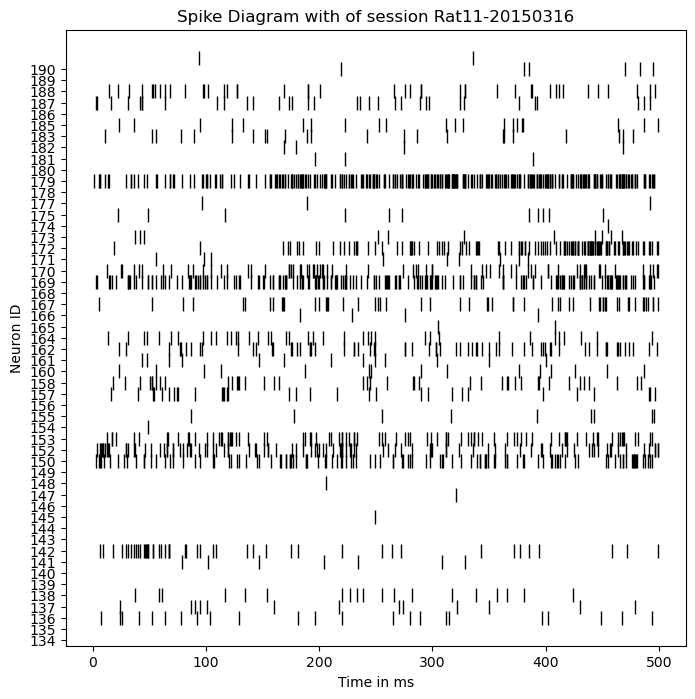

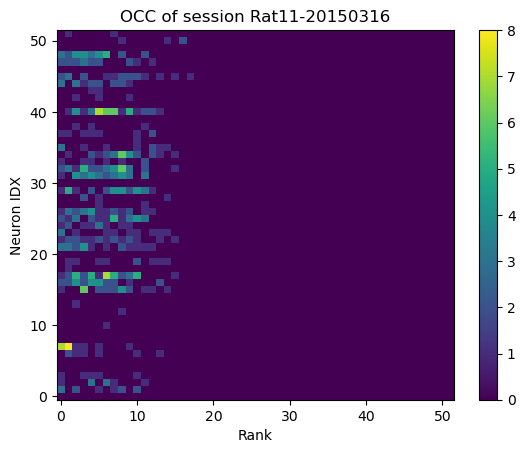

6 Session being processed is: Rat11-20150317


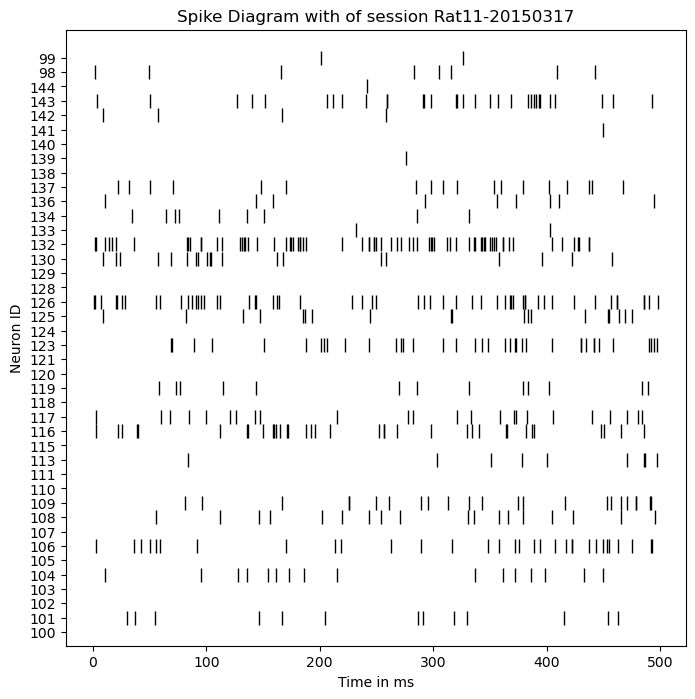

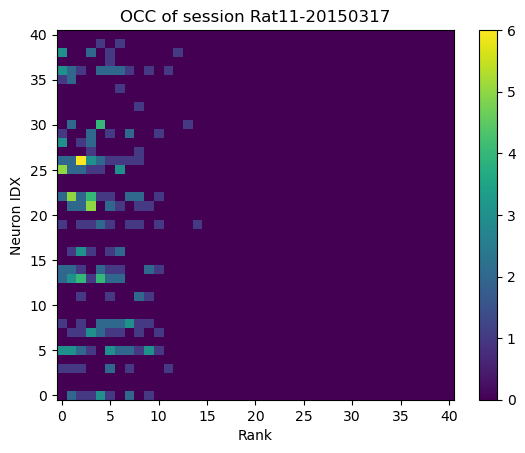

7 Session being processed is: Rat11-20150321


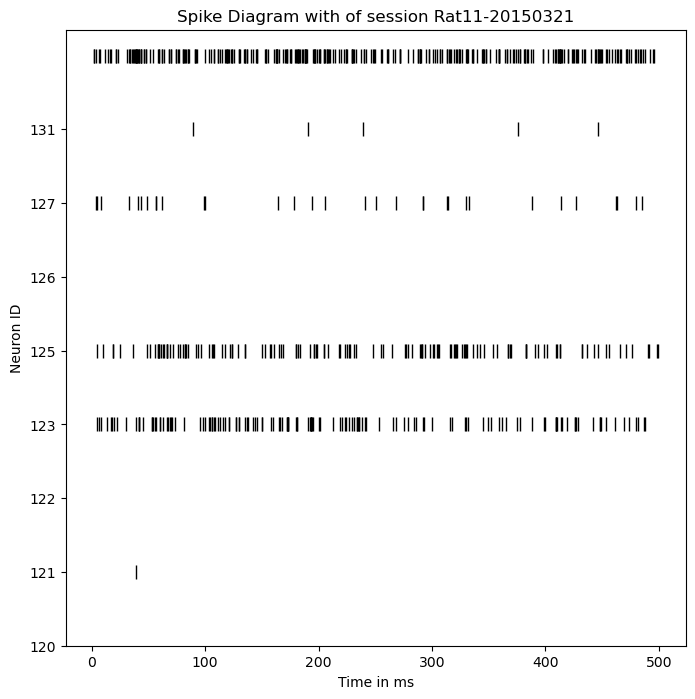

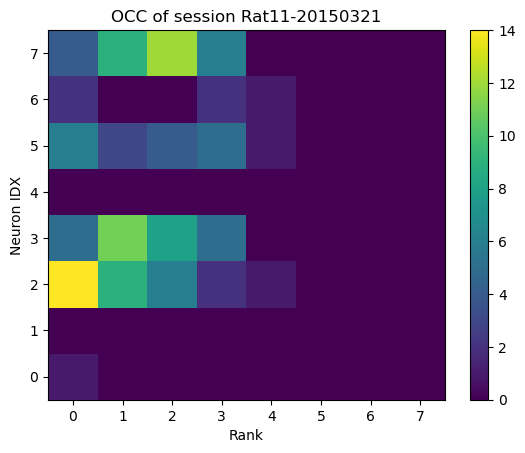

8 Session being processed is: Rat11-20150323


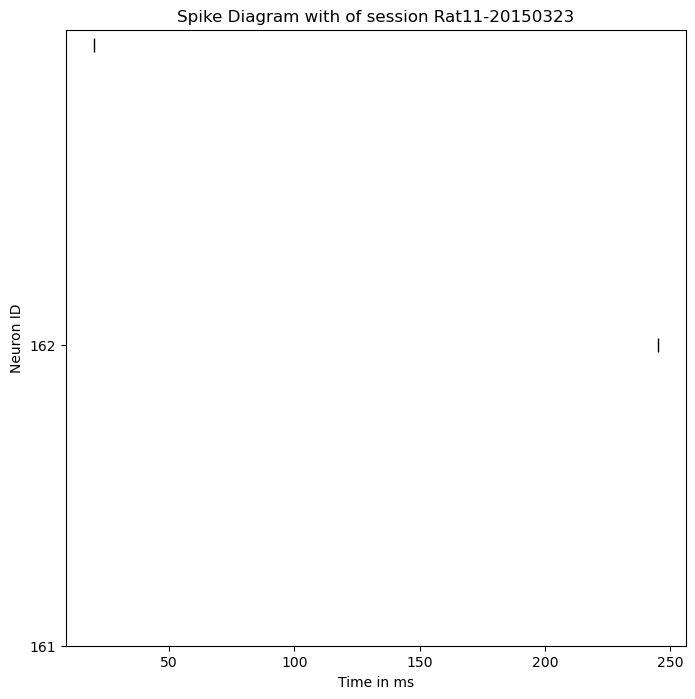

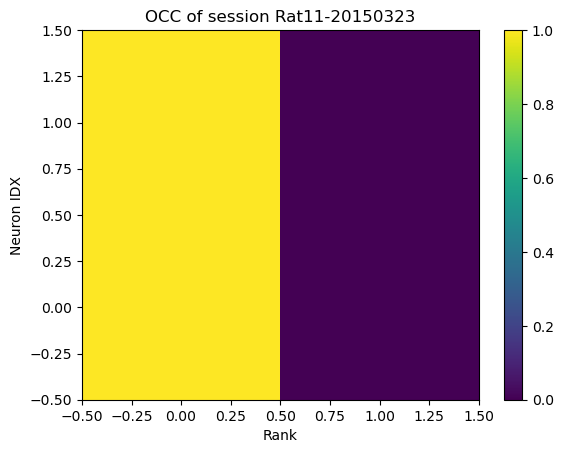

9 Session being processed is: Rat11-20150325


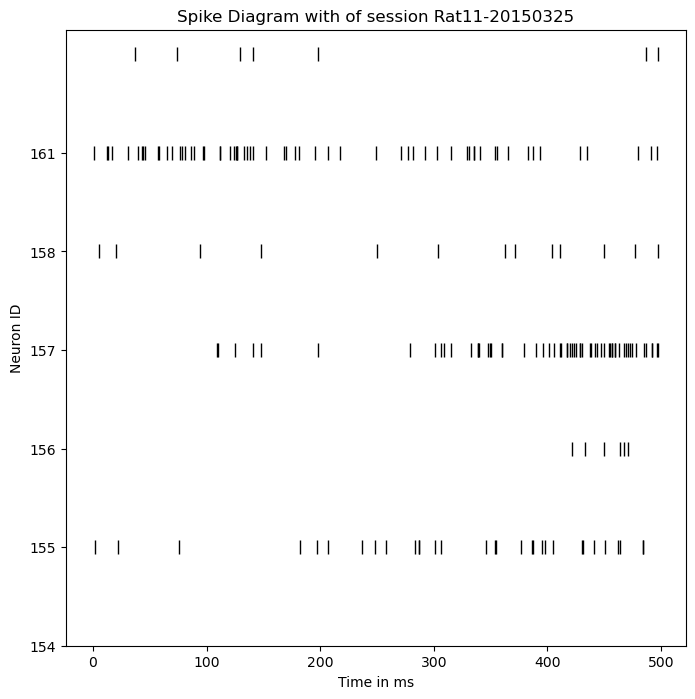

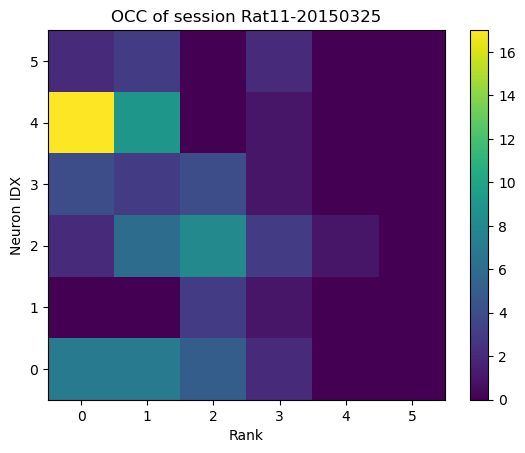

10 Session being processed is: Rat11-20150326


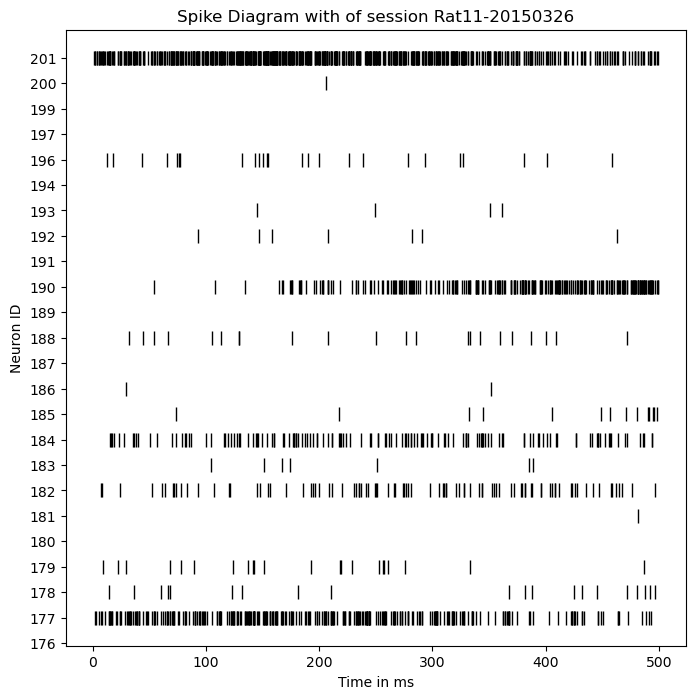

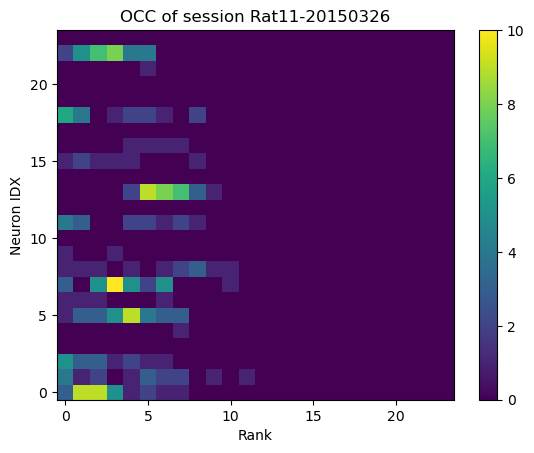

12 Session being processed is: Rat11-20150328


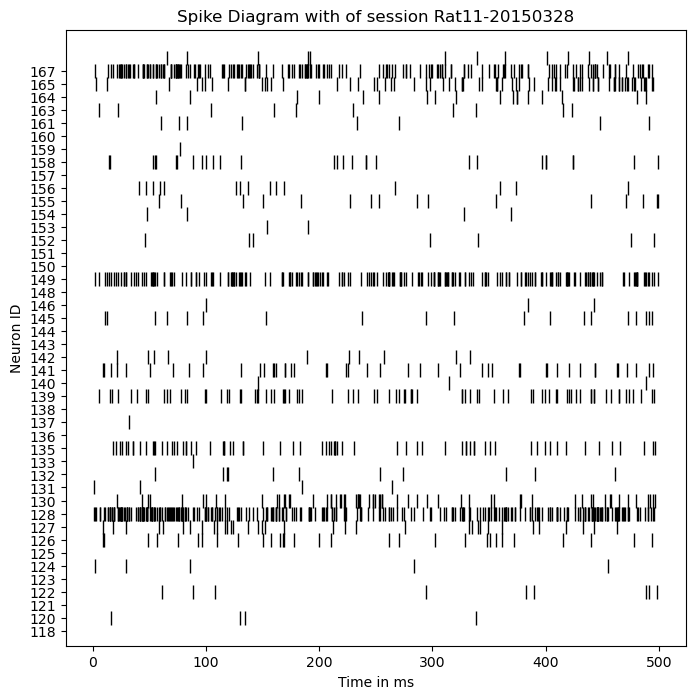

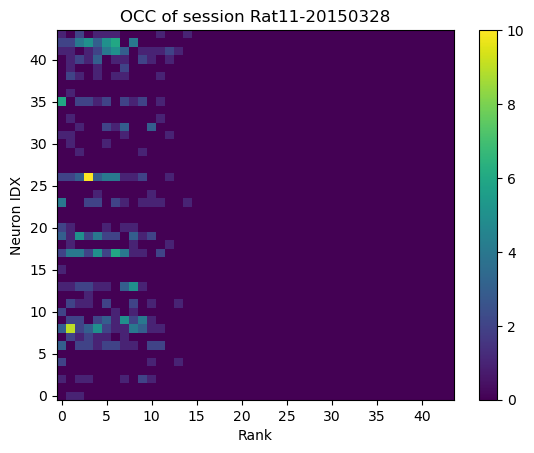

13 Session being processed is: Rat11-20150330


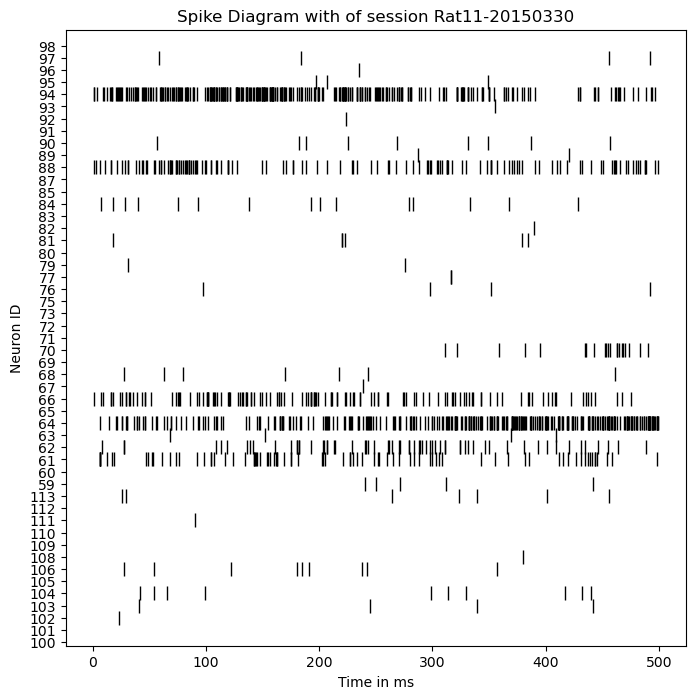

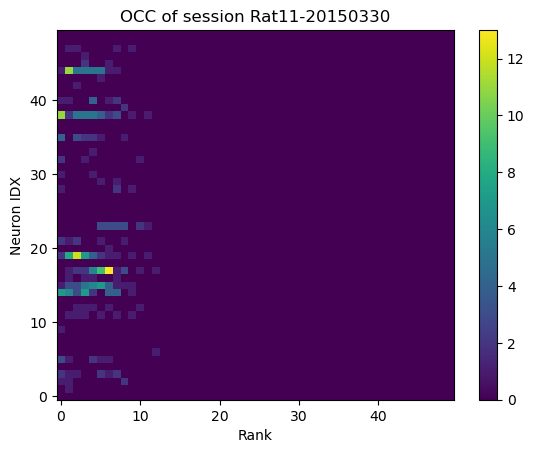

14 Session being processed is: Rat11-20150331


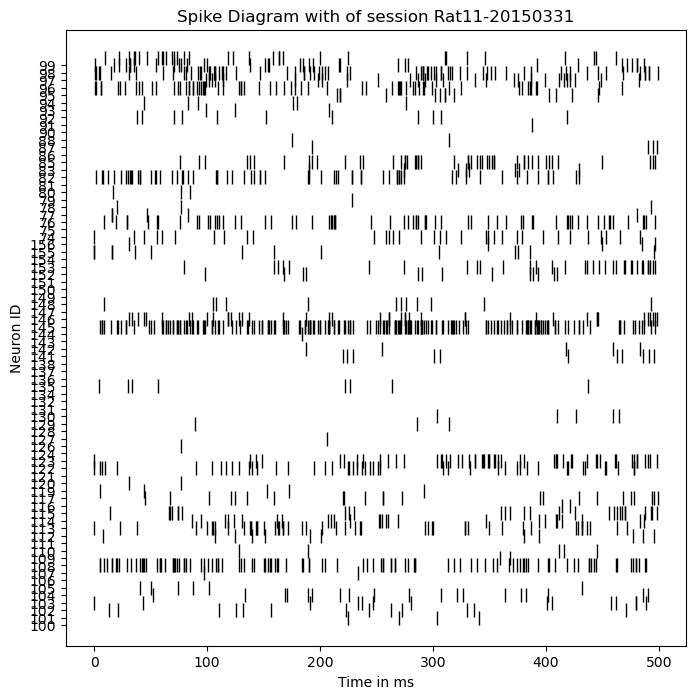

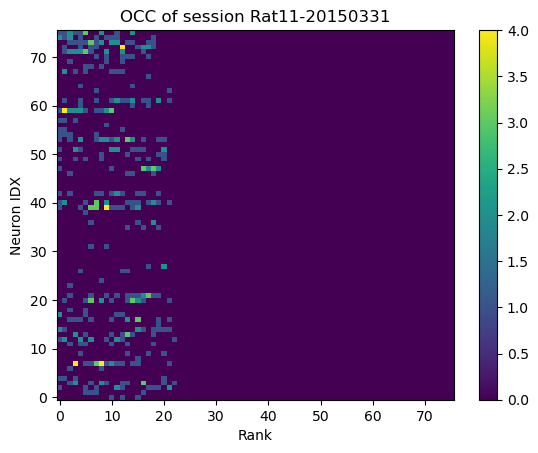

In [22]:
data = load_data('Rat11')
spks = data.get_spk()
rat_id = 3
rat = rats[rat_id]

n_sessions = 15
MI_all_sessions = np.zeros(n_sessions)
boundary_all_sessions = np.zeros(n_sessions)
surrogate_MI_all_sessions = np.zeros((n_sessions, 1000), dtype=float)

for s in range(n_sessions):
    if s == 11: #for rat 11 invalid session
         continue
    session_idx = s
    session, session_neurons, n_neurons, neuron_ids, start_t, end_t, puffs = session_vars()
    print(s, f"Session being processed is: {session}")
    
    spk_airpuff_matrix = spk_puff_matrix(puffs, 500, session_neurons)
    mi, occ, surrogates, boundary = MI_real_and_surrogates(spk_airpuff_matrix, 1000)
    MI_all_sessions[s] = mi
    boundary_all_sessions[s] = boundary
    surrogate_MI_all_sessions[s] = surrogates

    spike_diagram(neuron_ids, spk_airpuff_matrix, session)

    plt.imshow((occ), aspect='auto', origin='lower')
    plt.xlabel('Rank')
    plt.ylabel('Neuron IDX')
    plt.colorbar()
    plt.title(f"OCC of session {session}")
    plt.show()

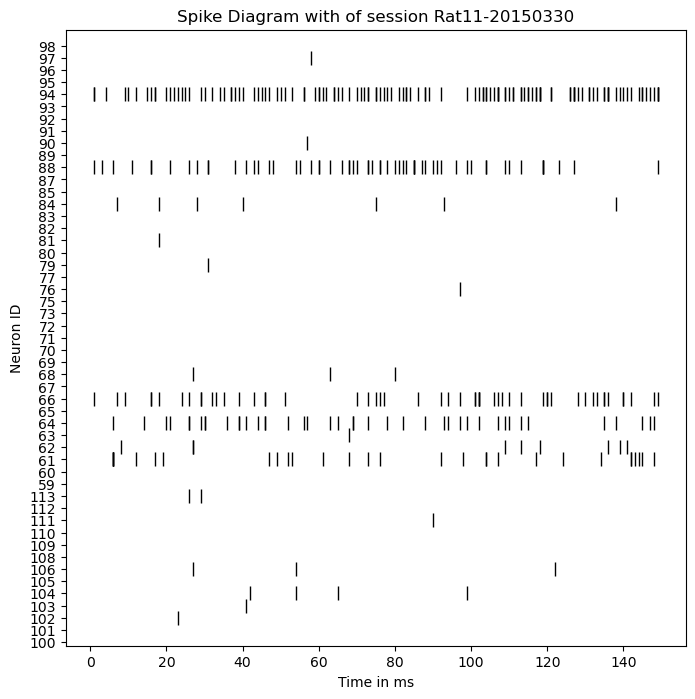

[ 29.  42.  53.  60. 129.] [14 17 19 38 44]


In [36]:
session_idx = 13
session, session_neurons, n_neurons, neuron_ids, start_t, end_t, puffs = session_vars()
# safe_moments = find_safe_moments(session, start_t, end_t)
spk_airpuff_matrix = spk_puff_matrix(puffs, 150, session_neurons)
spike_diagram(neuron_ids, spk_airpuff_matrix, session)
# print(neuron_ids[40], neuron_ids[39], neuron_ids[59], neuron_ids[71])
sum_per_neuron = np.sum(spk_airpuff_matrix, axis=(0, 2))
top_5_indices = np.argsort(sum_per_neuron)[-5:]  
top_5_values = sum_per_neuron[top_5_indices]
print(top_5_values, top_5_indices)

# num_plots = n_sessions
# cols = 5
# rows = (num_plots + cols - 1) // cols  # Ceiling division

# # Create subplots
# fig, axes = plt.subplots(rows, cols, figsize=(20, 12))
# axes = axes.flatten()  # Flatten to make indexing easier

# # Loop through and plot
# for n in range(num_plots):
#     plot_surrogates(surrogate_MI_all_sessions[n], boundary_all_sessions[n], MI_all_sessions[n], axes[n], n)

# # Hide unused subplots
# for ax in axes[num_plots:]:
#     ax.axis('off')

# plt.tight_layout()
# plt.show()

# Use z-scoring and finding ways to plot clearly

/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150402/Rat11-20150402.puf.evt
  self.__warning_msg(path)
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150318/Rat11-20150318-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150315/Rat11-20150315-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/larav

0 Session being processed is: Rat11-20150310


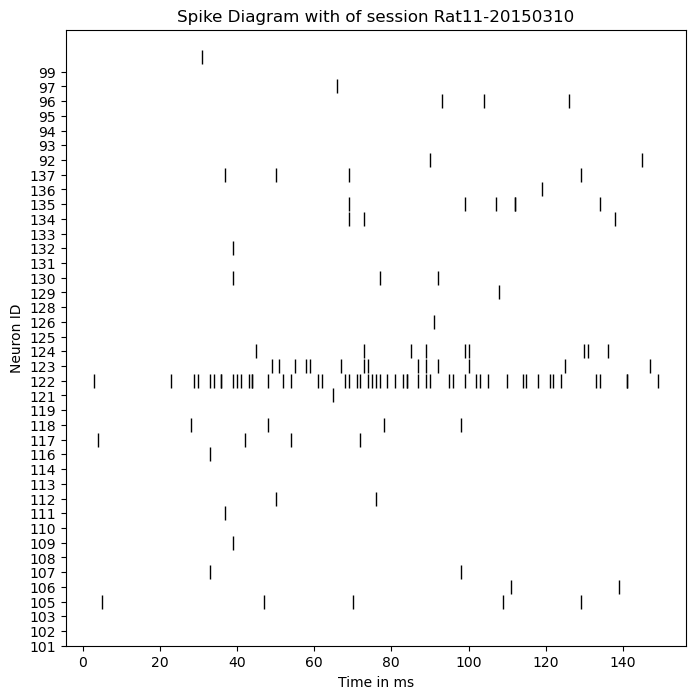

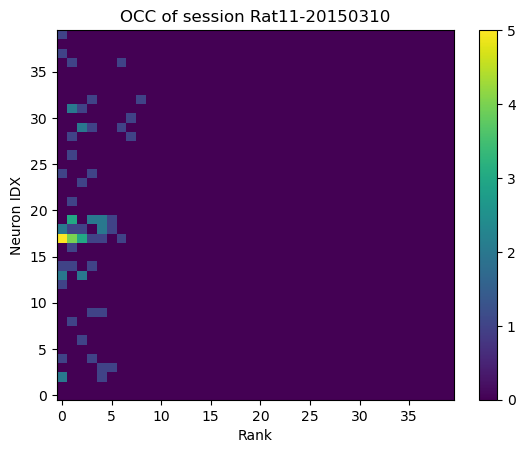

1 Session being processed is: Rat11-20150312


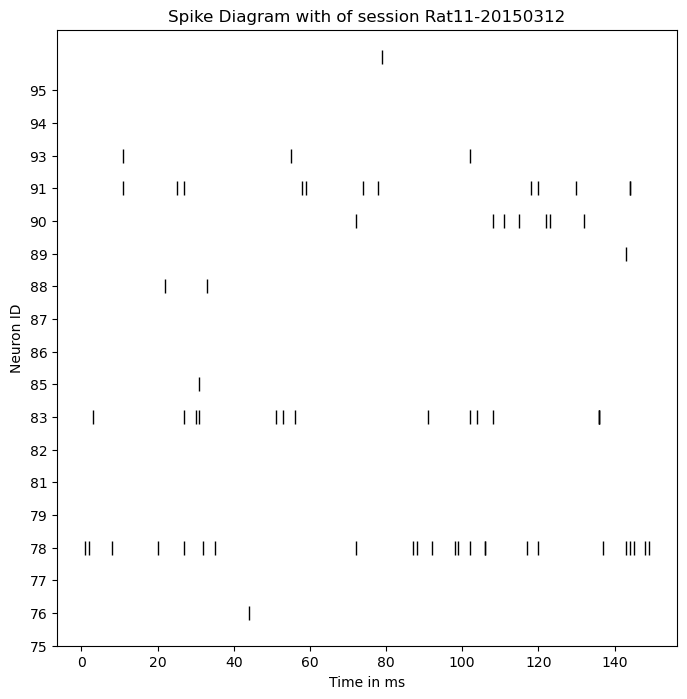

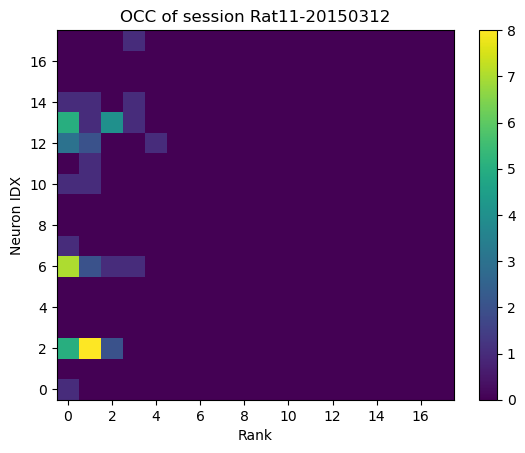

2 Session being processed is: Rat11-20150313


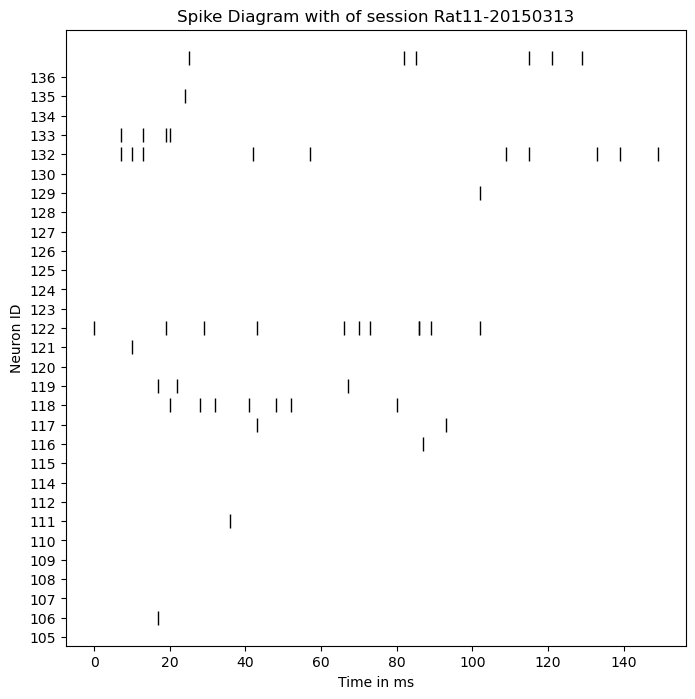

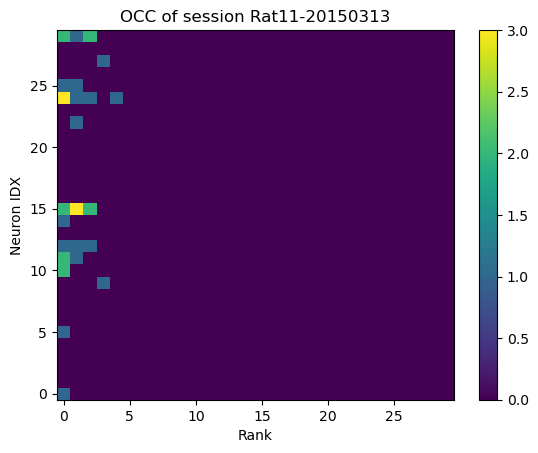

3 Session being processed is: Rat11-20150314


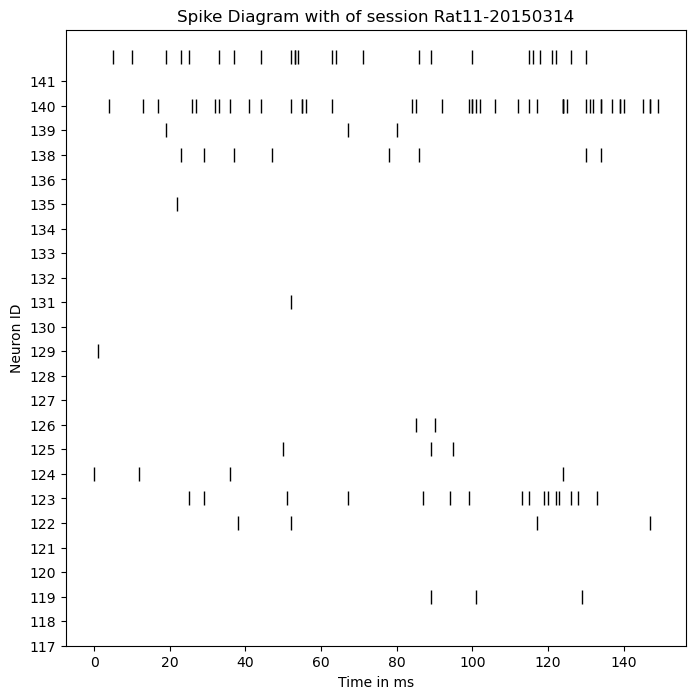

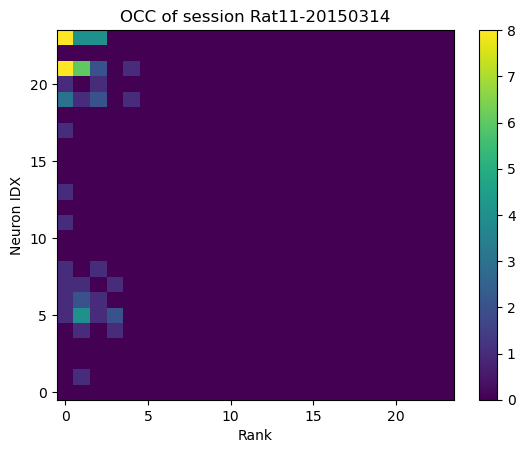

4 Session being processed is: Rat11-20150315


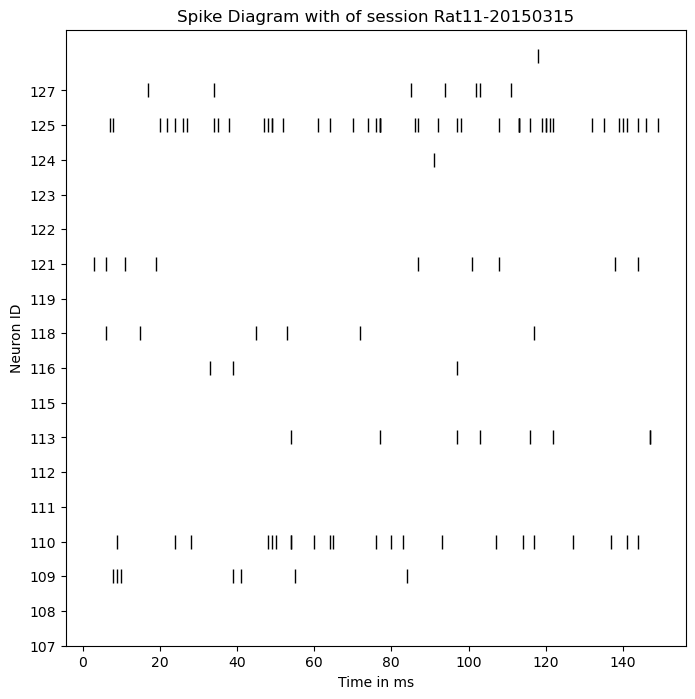

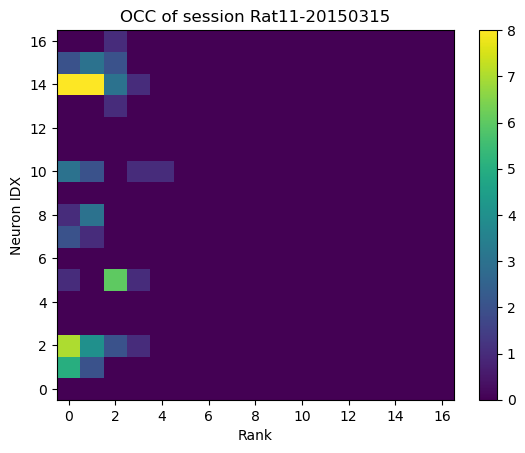

5 Session being processed is: Rat11-20150316


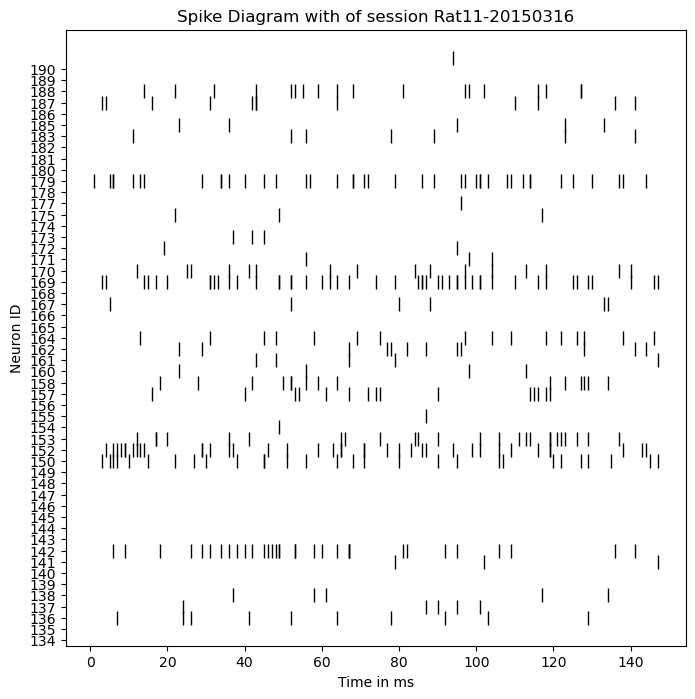

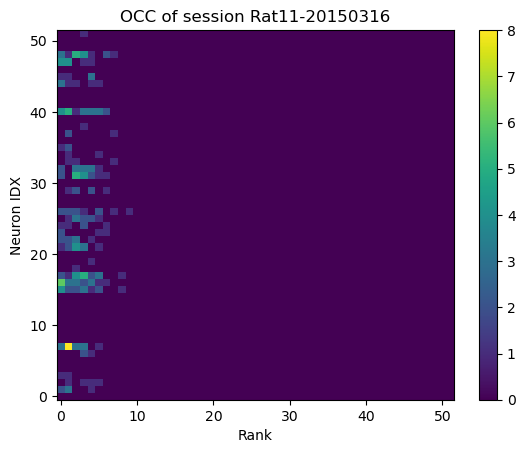

6 Session being processed is: Rat11-20150317


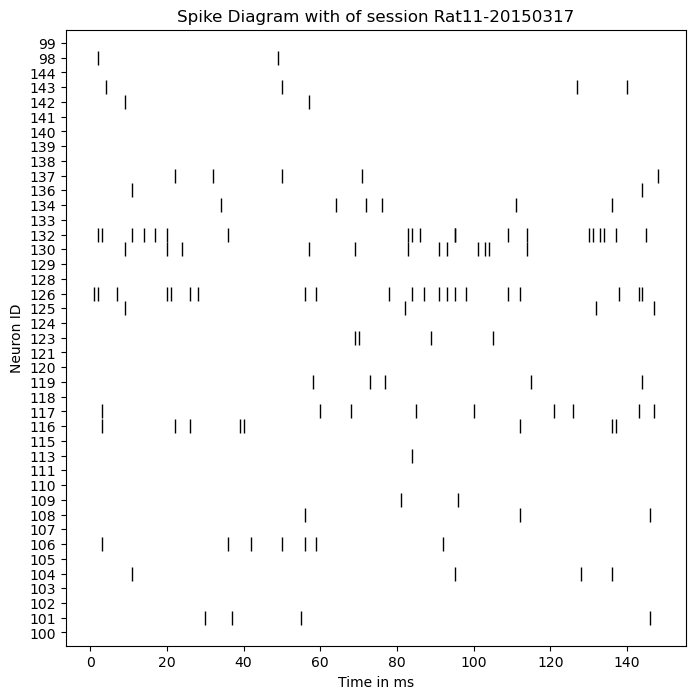

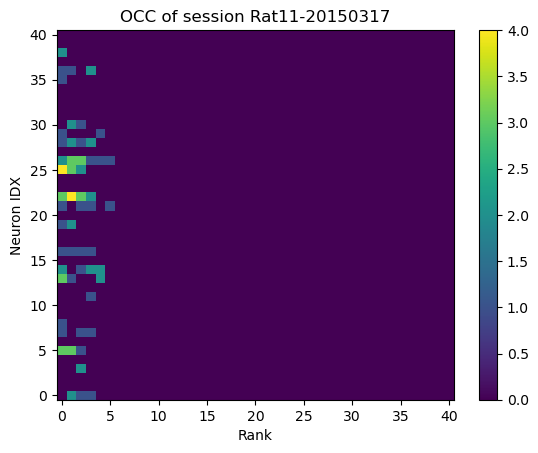

7 Session being processed is: Rat11-20150321


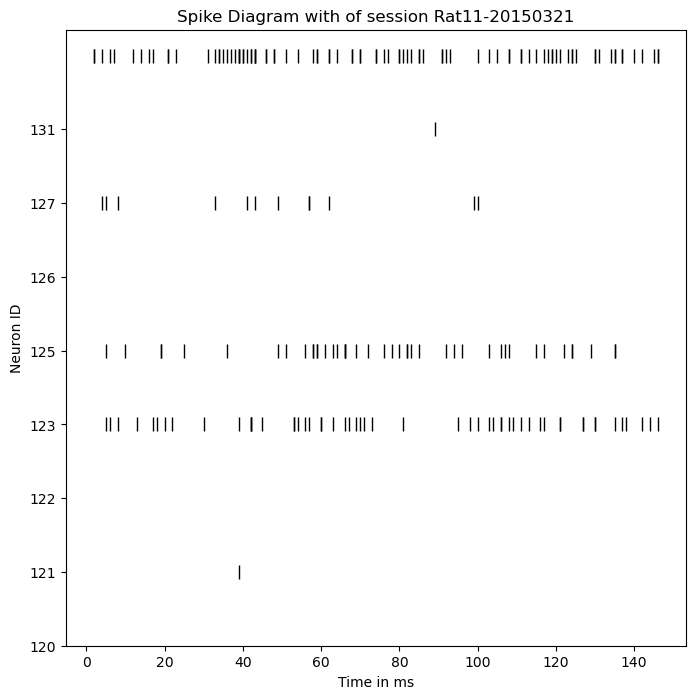

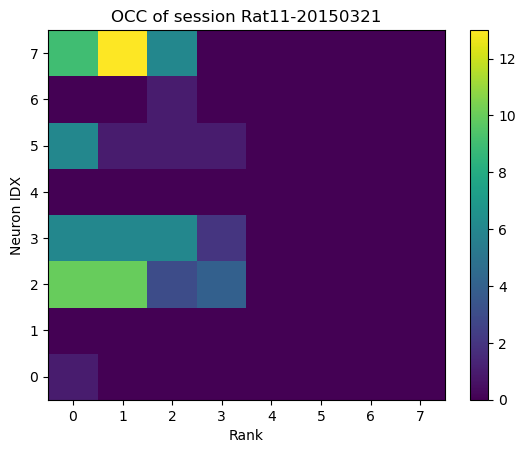

8 Session being processed is: Rat11-20150323


/var/folders/ns/_47zlc693097dwsy6flqxvxm0000gn/T/ipykernel_3226/3090061557.py:4: RuntimeWarning: invalid value encountered in scalar divide
  real_MI = (real_MI-m)/s
/var/folders/ns/_47zlc693097dwsy6flqxvxm0000gn/T/ipykernel_3226/3090061557.py:4: RuntimeWarning: invalid value encountered in divide
  real_MI = (real_MI-m)/s


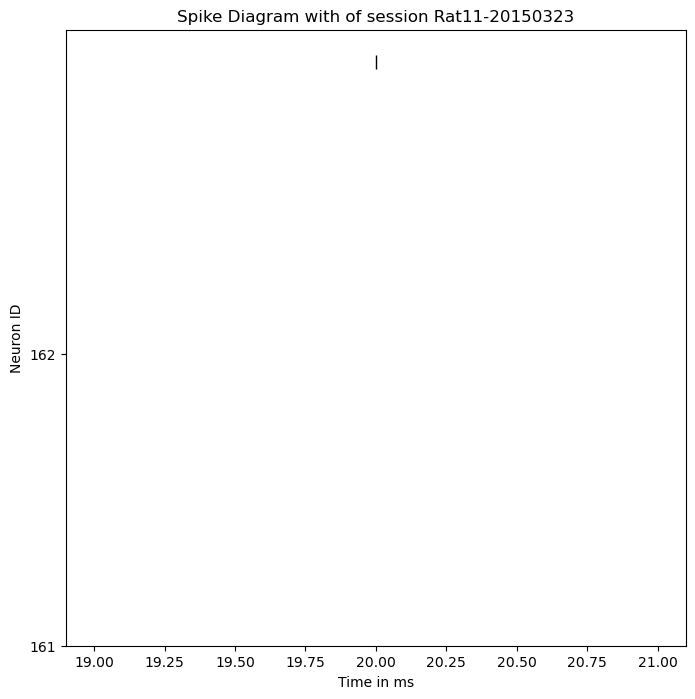

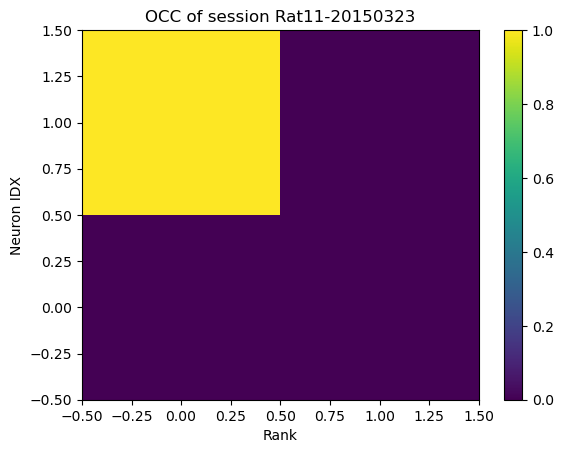

9 Session being processed is: Rat11-20150325


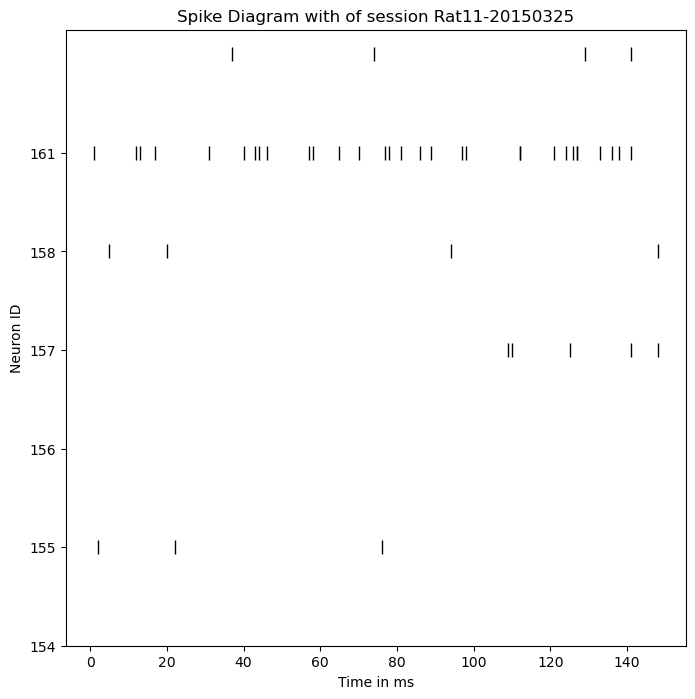

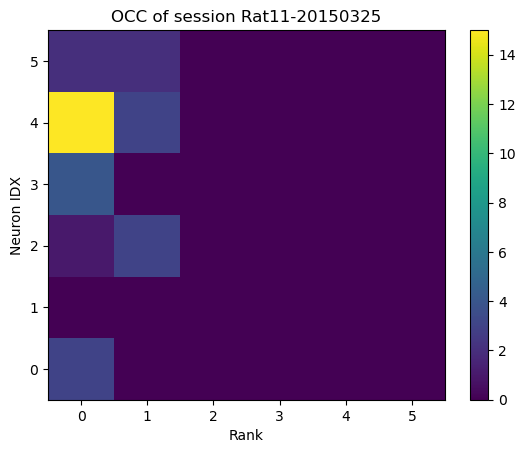

10 Session being processed is: Rat11-20150326


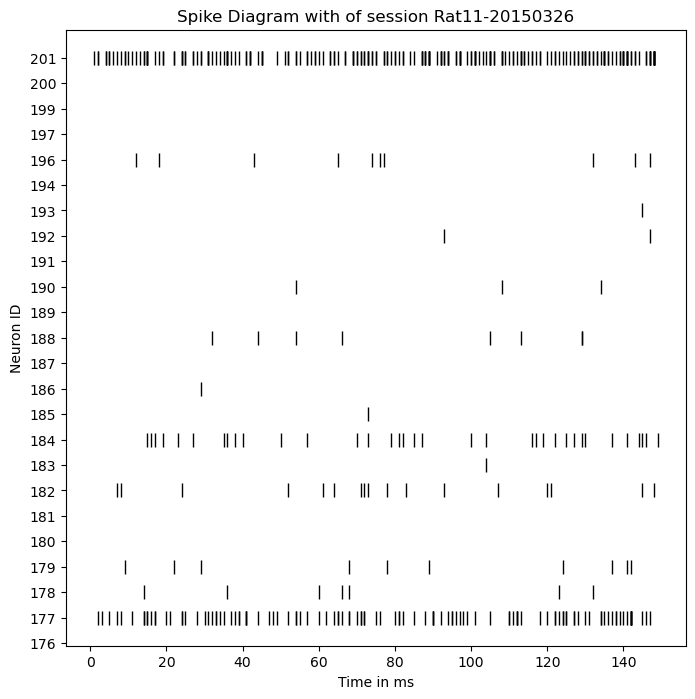

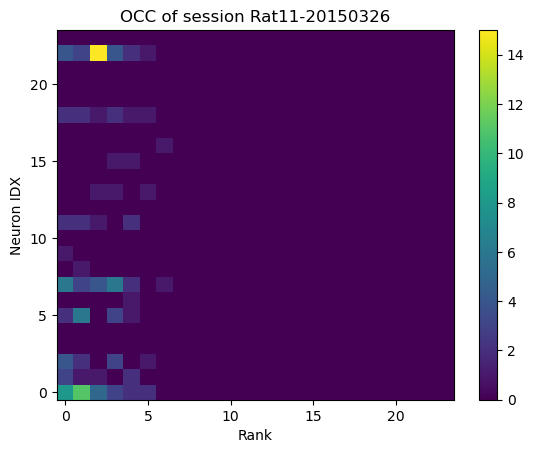

12 Session being processed is: Rat11-20150328


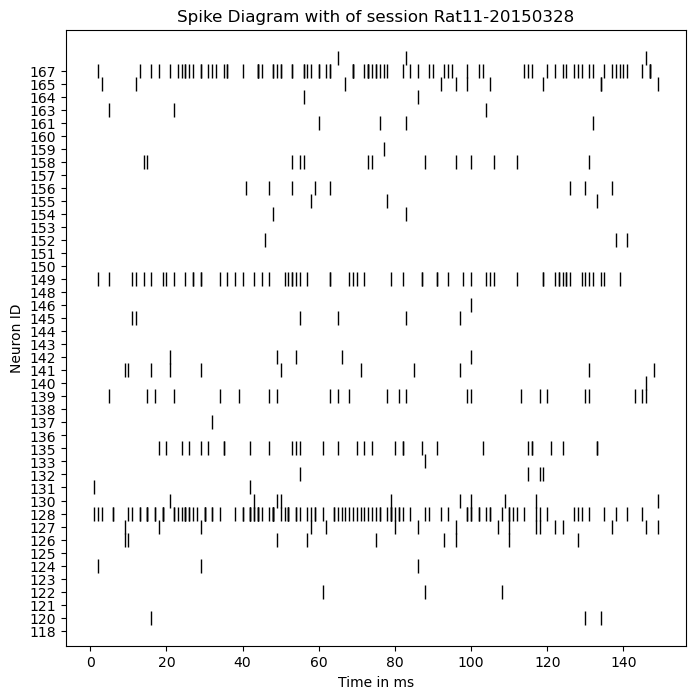

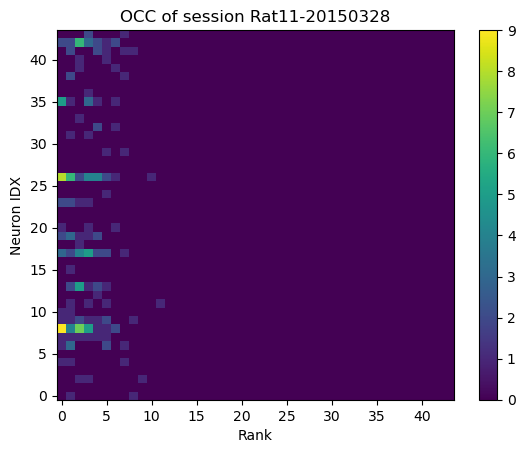

13 Session being processed is: Rat11-20150330


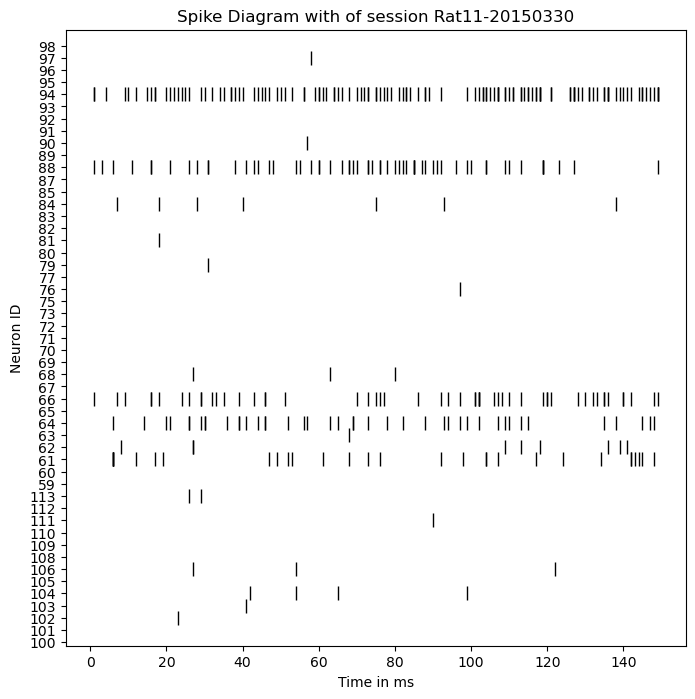

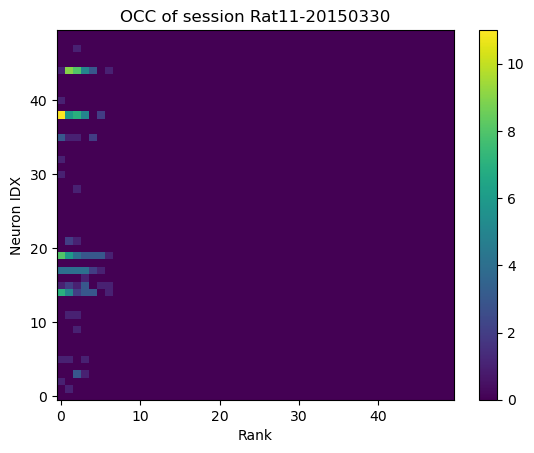

14 Session being processed is: Rat11-20150331


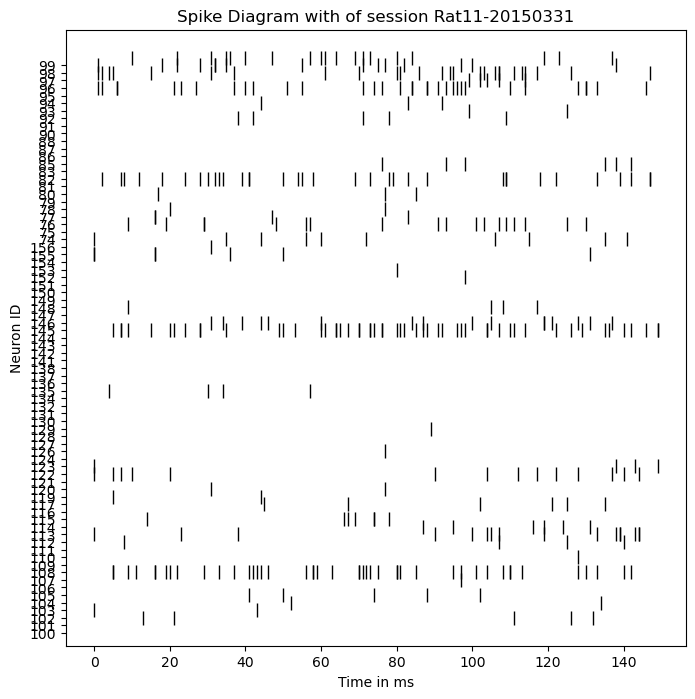

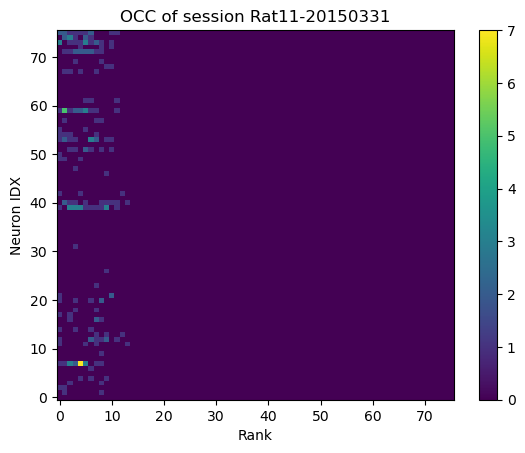

15 Session being processed is: Rat11-20150401


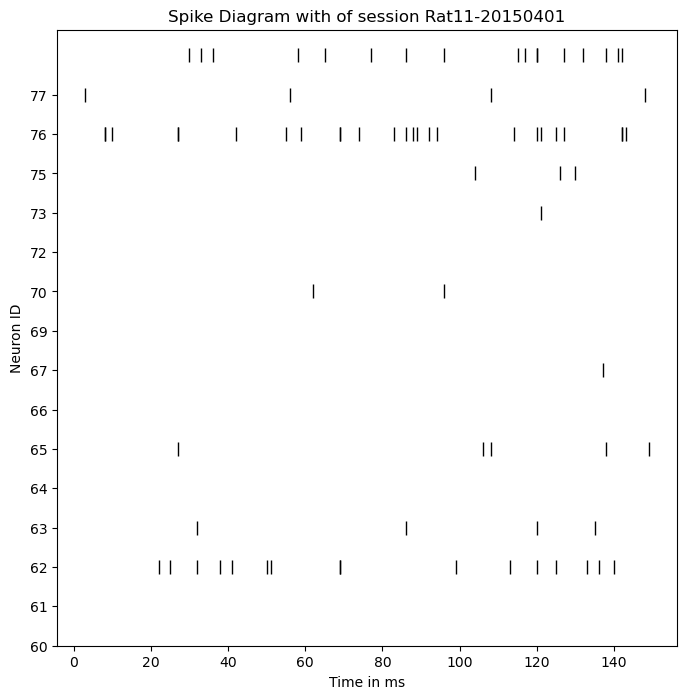

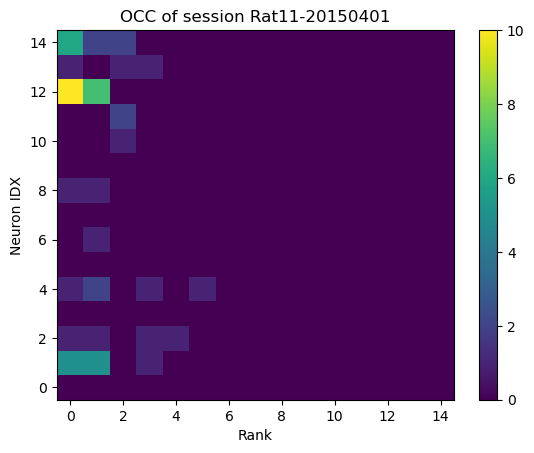

In [24]:
data = load_data('Rat11')
spks = data.get_spk()
rat_id = 3
rat = rats[rat_id]

n_sessions = 16
MI_all_sessions = np.zeros(n_sessions)
MI_z_all_sessions = np.zeros(n_sessions)
boundary_all_sessions_z = np.zeros(n_sessions)
surrogate_MI_all_sessions_z = np.zeros((n_sessions, 1000), dtype=float)

for s in range(n_sessions):
    if s == 11: #for rat 11 invalid session
         continue
    session_idx = s
    session, session_neurons, n_neurons, neuron_ids, start_t, end_t, puffs = session_vars()
    print(s, f"Session being processed is: {session}")
    
    spk_airpuff_matrix = spk_puff_matrix(puffs, 150, session_neurons)
    mi, occ, surrogates_z, boundary_z, mi_z = MI_real_and_surrogates_zscore(spk_airpuff_matrix, 1000)
    MI_all_sessions[s] = mi
    boundary_all_sessions_z[s] = boundary_z
    surrogate_MI_all_sessions_z[s] = surrogates_z
    MI_z_all_sessions[s] = mi_z
    
    spike_diagram(neuron_ids, spk_airpuff_matrix, session)

    plt.imshow((occ), aspect='auto', origin='lower')
    plt.xlabel('Rank')
    plt.ylabel('Neuron IDX')
    plt.colorbar()
    plt.title(f"OCC of session {session}")
    plt.show()


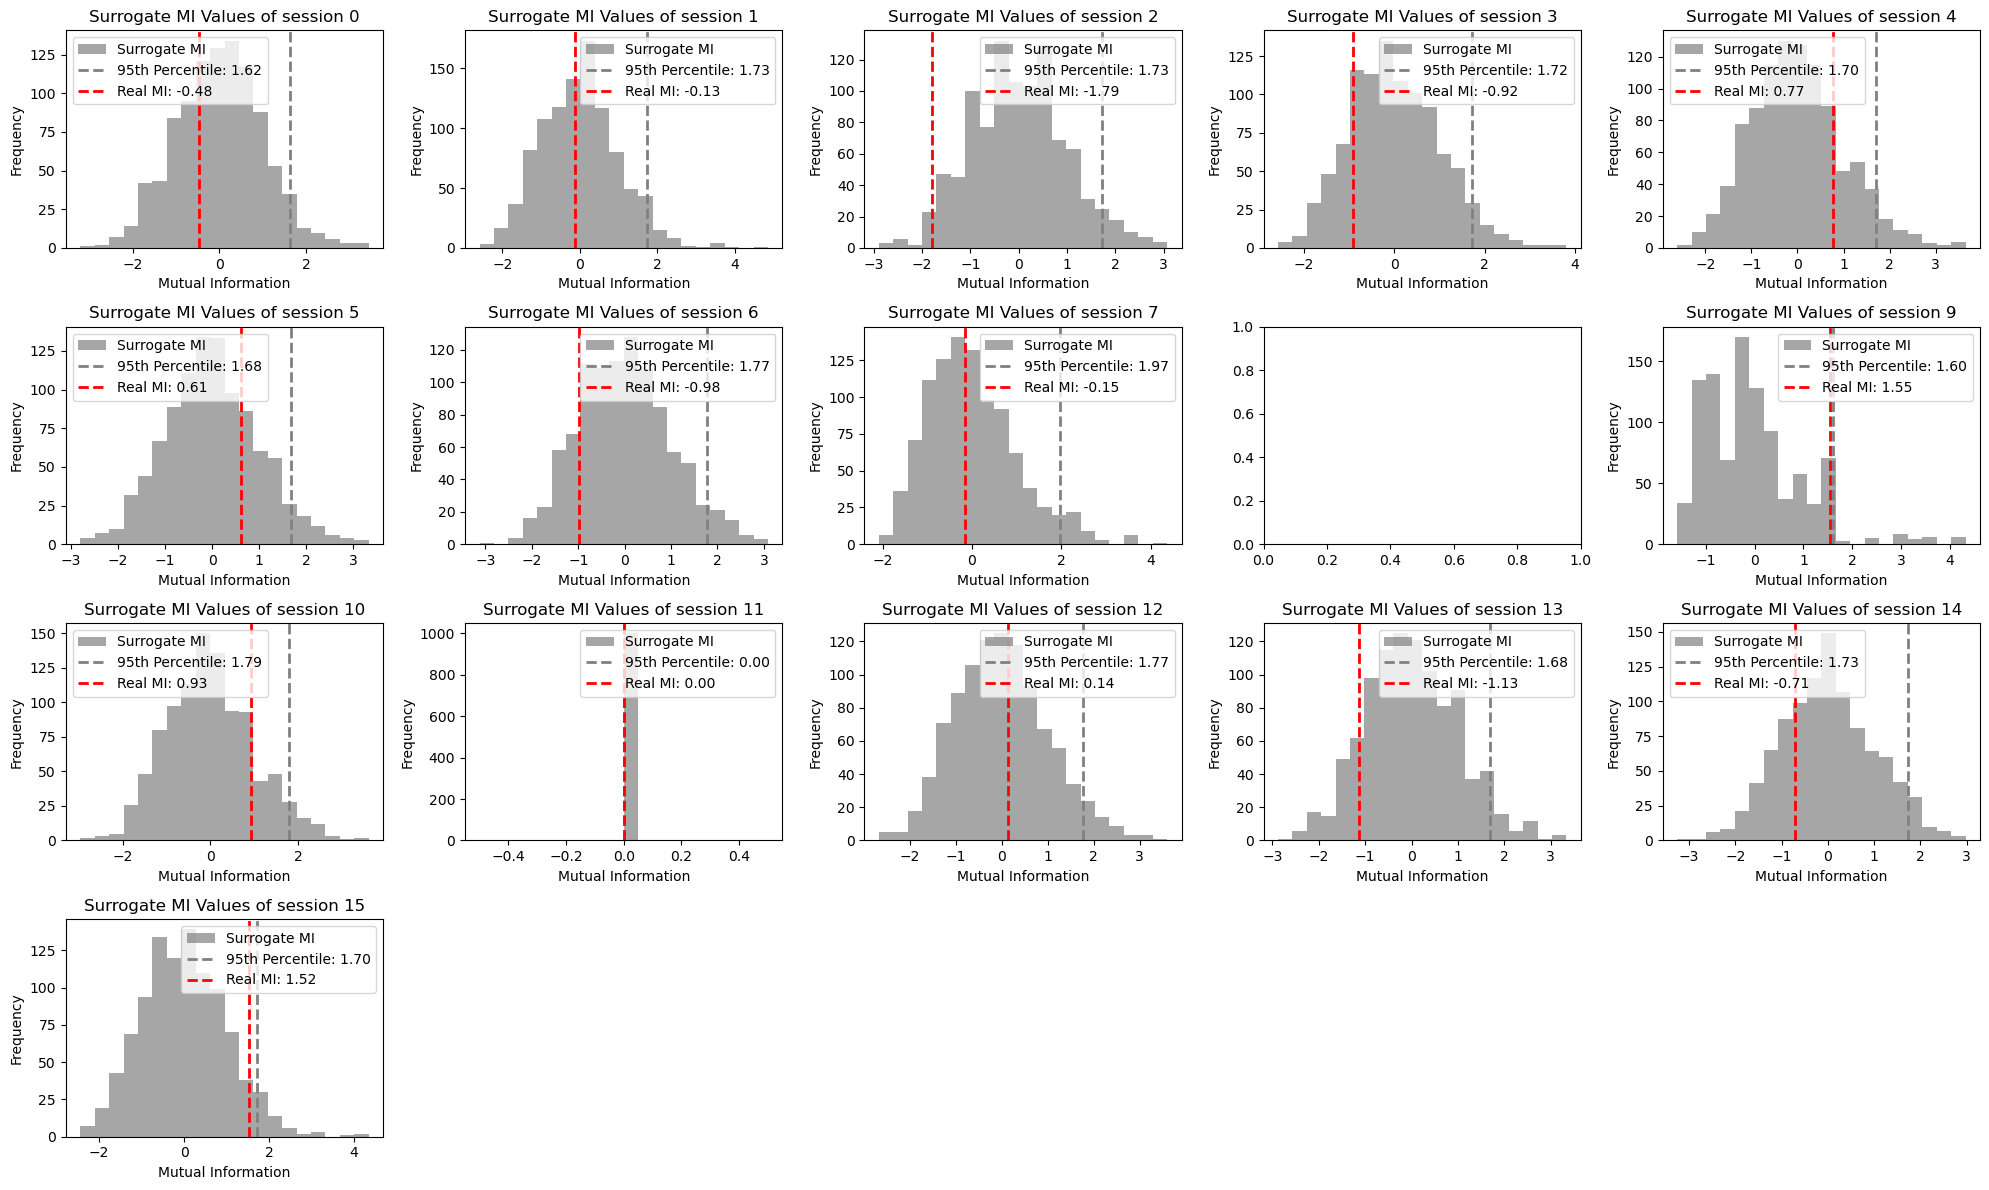

In [25]:
num_plots = n_sessions
cols = 5
rows = (num_plots + cols - 1) // cols  # Ceiling division

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 12))
axes = axes.flatten()  # Flatten to make indexing easier

# Loop through and plot
for n in range(num_plots):
    if n == 8:
        continue
    else:
        plot_surrogates(surrogate_MI_all_sessions_z[n], boundary_all_sessions_z[n], MI_z_all_sessions[n], axes[n], n)

# Hide unused subplots
for ax in axes[num_plots:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [26]:
b = (np.nanmean(boundary_all_sessions_z))

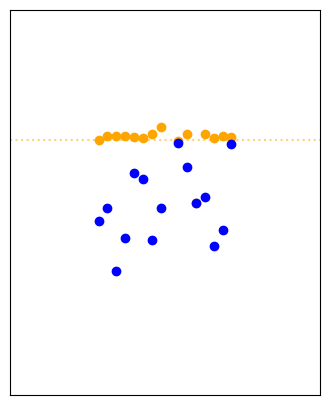

In [28]:
plt.figure(figsize=(4, 5))
x = np.arange(len(MI_z_all_sessions))
y = np.arange(len(boundary_all_sessions_z))
session_indices = np.arange(len(MI_z_all_sessions)) 

# Scatter plot for real MI values
plt.scatter(session_indices, MI_z_all_sessions, color='blue', label='Real MI Value', zorder=3)

# Horizontal lines for surrogate boundaries
plt.scatter(session_indices, boundary_all_sessions_z, color='orange', label='Surrogate MI Value')
plt.axhline(b, linestyle=':', alpha=0.5, color='orange', label='Significance boundary')
# plt.xticks(session_indices)
# plt.xlabel("Session Index")
# plt.ylabel("MI Value")
plt.ylim(-5, 5)
plt.xlim(-10, 25)
plt.yticks([])
plt.xticks([])
# plt.legend(loc='lower right')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.title("Real MI vs Surrogate MI")
# plt.savefig('stimlock_MI.png')
# plt.savefig('stimlock_MI.svg')
plt.show()



In [19]:
data = load_data('Rat11')
spks = data.get_spk()
rat_id = 3
rat = rats[rat_id]


session_idx = 13
session, session_neurons, n_neurons, neuron_ids, start_t, end_t, puffs = session_vars()
# print(s, f"Session being processed is: {session}")

spk_airpuff_matrix = spk_puff_matrix(puffs, 500, session_neurons)
mi, occ, surrogates, boundary = MI_real_and_surrogates(spk_airpuff_matrix, 1000)


/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150402/Rat11-20150402.puf.evt
  self.__warning_msg(path)
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150318/Rat11-20150318-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150315/Rat11-20150315-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/larav

In [33]:
def plot_overlayed_zscored_surrogates(surrogates_list, mi_values, boundaries):
    """
    Plot all z-scored surrogate distributions overlayed in one plot with a light grey shade.

    Parameters:
    - surrogates_list (list of arrays): A list containing the surrogate MI values for all neurons.
    """
    plt.figure(figsize=(10, 6))
    plt.xlabel("Z-Scored Mutual Information (MI)")
    plt.ylabel("Density")
    plt.title("Overlayed Z-Scored Surrogate Distributions")
    plt.legend()
    plt.grid(alpha=0.3)
    try:
        # Loop through each neuron's surrogate values
        for i, surrogates in enumerate (surrogates_list):
            if i == 6:
                continue
            # Compute z-scores for the current surrogate set
            zscored_surrogates = (surrogates - np.mean(surrogates)) / np.std(surrogates)
            
            # Plot the histogram of the z-scored surrogates
            plt.hist(zscored_surrogates, bins=20, color='lightgray', alpha=0.5, density=True)
            zscored_value = zscore_by_surr(mi_values[i], surrogates_list[i])  # Use the first MI value
            plt.axvline(zscored_value, color='red', alpha = 0.6,linestyle='dashed', linewidth=1.5)
            boundary = boundaries[i]
            plt.axvline(boundary, color='grey',  alpha = 0.6,linestyle='dashed', linewidth=1.5)
            plt.savefig('overlaid_surrogates.svg')
        
    except:
        print('Empty?')
    plt.show()

/var/folders/ns/_47zlc693097dwsy6flqxvxm0000gn/T/ipykernel_3226/1339093697.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Empty?


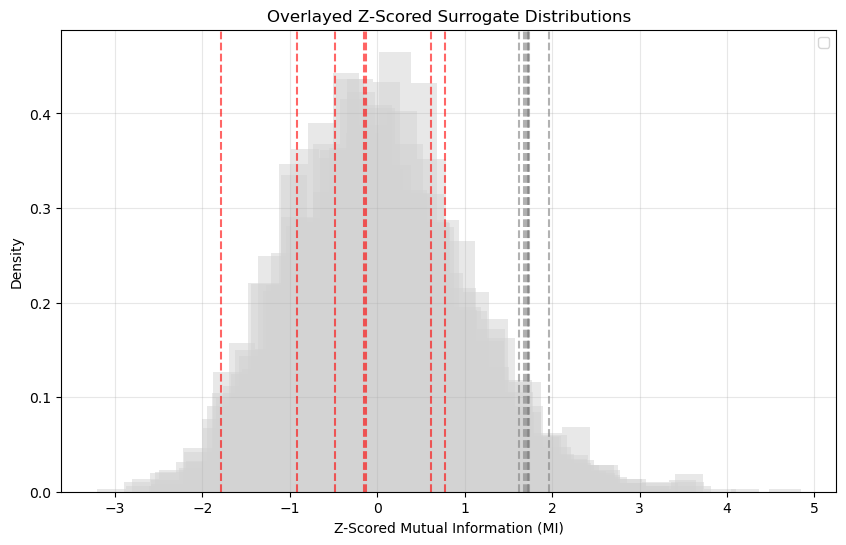

In [34]:
plot_overlayed_zscored_surrogates(surrogate_MI_all_sessions_z, MI_z_all_sessions, boundary_all_sessions_z)

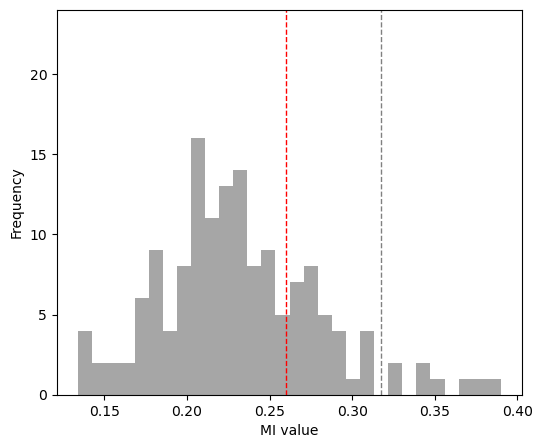

In [75]:
plt.figure(figsize=(6,5))
plt.hist(surrogates, bins=30, color='grey', alpha=0.7, label='Surrogates')
plt.axvline(boundary, color='grey', linestyle='dashed', linewidth=1, label='Significance boundary')
plt.axvline(mi, color='red', linestyle='dashed', linewidth=1, label='Real MI value')
plt.xlabel('MI value')
plt.ylabel('Frequency')
# plt.legend()
# plt.savefig('stimlock_sur_example.png')
plt.ylim(0, 24)
plt.savefig('surrogates_example_.svg')
plt.show()